
This script is the postprocess of the hindcast over 2000-2020 for 71 glaciers in Svalbard.

In [1]:
# import library
import os
import pandas as pd
import json
import ast
import csv  # Import the standard csv module
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import linregress
import statistic_tool as stats_t
from typing import List, Dict
from matplotlib.gridspec import GridSpec
from scipy.stats import ks_2samp  # Import K-S test function

In [ ]:
# workspace path
# Get the current working directory
current_path = os.getcwd()
print("Current Working Directory:", current_path)
# Get the parent directory
parent_path = os.path.dirname(current_path)
# model output path
model_output_fp = os.path.join(parent_path,'Output','Calibration','modeloutput')
print("model_output_fp is",model_output_fp)


In [ ]:
# regional path
# region id
region_id = [7]
# Extract the first element from the list
region_id_value = region_id[0]

# Format the region_id
reg_id = f"{region_id_value:02}"  # Uses f-string formatting
# Alternatively, you could use:
# reg_id = str(region_id_value).zfill(2)

print("Region ID:", reg_id)

# regional model output path
model_output_fp_region = os.path.join(model_output_fp,reg_id)

print(model_output_fp_region)

# Get the path of AMIS_counts_info
model_param_fp = os.path.join(parent_path,'Output','Calibration','parameter')
model_param_fp_region = os.path.join(model_param_fp,reg_id)
print(model_param_fp_region)

# regional postprocessing output path
postpro_output_fp_region = os.path.join(model_output_fp,'..','Postprocessing',reg_id)
print(postpro_output_fp_region)

# 1. get the statistic info from the model output

In [4]:

all_glac_data_stats,mean_data,sum_data = stats_t.read_extract_data_region(region_output_path = model_output_fp_region, region_params_path= model_param_fp_region,reg_id= reg_id, data_index = 'Annual')

In [ ]:
sum_dL_SQ_0020_raw_m = stats_t.extract_and_save_ensemble_data(
     sum_data,
    save_path = postpro_output_fp_region,
     key_value='lengthchange_dLdt_model_array_annual_myr',
     file_name='sum_dL_SQ_0020_raw_m',
      period='2000_2020'
 )

In [ ]:
sum_dL_SQ_1020_raw_m = stats_t.extract_and_save_ensemble_data(
     sum_data,
    save_path = postpro_output_fp_region,
     key_value='lengthchange_dLdt_model_array_annual_myr',
     file_name='sum_dL_SQ_1020_raw_m',
      period='2010_2020'
 )

In [ ]:
sum_dL_SQ_0010_raw_m = stats_t.extract_and_save_ensemble_data(
     sum_data,
    save_path = postpro_output_fp_region,
     key_value='lengthchange_dLdt_model_array_annual_myr',
     file_name='sum_dL_SQ_0010_raw_m',
      period='2000_2010'
 )

In [ ]:
mean_MB_clim_1020_raw_mwe = stats_t.extract_and_save_ensemble_data(
     mean_data,
    save_path = postpro_output_fp_region,
     key_value='massbalclim_TMS_model_array_annual_mwea',
     file_name='mean_MB_clim_1020_raw_mwe',
      period='2010_2020'
 )

In [ ]:
mean_MB_clim_0020_raw_mwe = stats_t.extract_and_save_ensemble_data(
     mean_data,
    save_path = postpro_output_fp_region,
     key_value='massbalclim_TMS_model_array_annual_mwea',
     file_name='mean_MB_clim_0020_raw_mwe',
      period='2000_2020'
 )

In [ ]:
mean_MB_clim_0010_raw_mwe = stats_t.extract_and_save_ensemble_data(
     mean_data,
    save_path = postpro_output_fp_region,
     key_value='massbalclim_TMS_model_array_annual_mwea',
     file_name='mean_MB_clim_0010_raw_mwe',
      period='2000_2010'
 )

In [ ]:
mean_0010_FA_raw_Gta = stats_t.extract_and_save_ensemble_data(
     mean_data,
    save_path = postpro_output_fp_region,
     key_value='calving_flux_Gta_TMS_model_array_annual',
     file_name='mean_0010_FA_raw_Gta',
      period='2000_2010'
 )

In [ ]:
mean_0020_FA_raw_Gta = stats_t.extract_and_save_ensemble_data(
     mean_data,
    save_path = postpro_output_fp_region,
     key_value='calving_flux_Gta_TMS_model_array_annual',
     file_name='mean_0020_FA_raw_Gta',
      period='2000_2020'
 )

In [ ]:
mean_1020_FA_raw_Gta = stats_t.extract_and_save_ensemble_data(
     mean_data,
    save_path = postpro_output_fp_region,
     key_value='calving_flux_Gta_TMS_model_array_annual',
     file_name='mean_1020_FA_raw_Gta',
      period='2010_2020'
 )

In [ ]:
mean_1020_FA_raw_mwea = stats_t.extract_and_save_ensemble_data(
     mean_data,
    save_path = postpro_output_fp_region,
     key_value='FA_mwea_TMS_model_array_annual',
     file_name='mean_1020_FA_raw_mwea',
      period='2010_2020'
 )

In [ ]:
mean_0020_FA_raw_mwea = stats_t.extract_and_save_ensemble_data(
     mean_data,
    save_path = postpro_output_fp_region,
     key_value='FA_mwea_TMS_model_array_annual',
     file_name='mean_0020_FA_raw_mwea',
      period='2000_2020'
 )

In [ ]:
mean_0010_FA_raw_mwea = stats_t.extract_and_save_ensemble_data(
     mean_data,
    save_path = postpro_output_fp_region,
     key_value='FA_mwea_TMS_model_array_annual',
     file_name='mean_0010_FA_raw_mwea',
      period='2000_2010'
 )

In [ ]:
# Call the function and get the output DataFrames
result_dataframes = stats_t.extract_dataframes(all_glac_data_stats)



In [36]:
# Define a list of tuples containing DataFrame names and their corresponding output file names
stats_to_extract = [
    # Mean dL/dt statistics
    ('mean_stats_20002010_lengthchange_dLdt_model_array_annual_myr', 'mean_0010_dLdt_SQ_myr'),
    ('mean_stats_20102020_lengthchange_dLdt_model_array_annual_myr', 'mean_1020_dLdt_SQ_myr'),
    ('mean_stats_20002020_lengthchange_dLdt_model_array_annual_myr', 'mean_0020_dLdt_SQ_myr'),

    # Sum of dL/dt statistics
    ('sum_stats_20002010_lengthchange_dLdt_model_array_annual_myr', 'sum_0010_dL_SQ_m'),
    ('sum_stats_20102020_lengthchange_dLdt_model_array_annual_myr', 'sum_1020_dL_SQ_m'),
    ('sum_stats_20002020_lengthchange_dLdt_model_array_annual_myr', 'sum_0020_dL_SQ_m'),

    # Mean TMS length change statistics
    ('mean_stats_20002010_lengthchange_m_TMS_model_array_annual', 'mean_0010_dLdt_FL_myr'),
    ('mean_stats_20102020_lengthchange_m_TMS_model_array_annual', 'mean_1020_dLdt_FL_myr'),
    ('mean_stats_20002020_lengthchange_m_TMS_model_array_annual', 'mean_0020_dLdt_FL_myr'),

    # Sum of TMS length change statistics
    ('sum_stats_20002010_lengthchange_m_TMS_model_array_annual', 'sum_0010_dL_FL_m'),
    ('sum_stats_20102020_lengthchange_m_TMS_model_array_annual', 'sum_1020_dL_FL_m'),
    ('sum_stats_20002020_lengthchange_m_TMS_model_array_annual', 'sum_0020_dL_FL_m'),

    # Mean calving flux statistics
    ('mean_stats_20002010_calving_flux_Gta_TMS_model_array_annual', 'mean_0010_FA_Gta'),
    ('mean_stats_20102020_calving_flux_Gta_TMS_model_array_annual', 'mean_1020_FA_Gta'),
    ('mean_stats_20002020_calving_flux_Gta_TMS_model_array_annual', 'mean_0020_FA_Gta'),

    # Sum of calving flux statistics
    ('sum_stats_20002010_calving_flux_Gta_TMS_model_array_annual', 'sum_0010_FA_Gt'),
    ('sum_stats_20102020_calving_flux_Gta_TMS_model_array_annual', 'sum_1020_FA_Gt'),
    ('sum_stats_20002020_calving_flux_Gta_TMS_model_array_annual', 'sum_0020_FA_Gt'),

    # Mean mass balance clim statistics
    ('mean_stats_20002010_massbalclim_TMS_model_array_annual_mwea', 'mean_0010_mb_clim_mwea'),
    ('mean_stats_20102020_massbalclim_TMS_model_array_annual_mwea', 'mean_1020_mb_clim_mwea'),
    ('mean_stats_20002020_massbalclim_TMS_model_array_annual_mwea', 'mean_0020_mb_clim_mwea'),

    # Sum of mass balance clim statistics
    ('sum_stats_20002010_massbalclim_TMS_model_array_annual_mwea', 'sum_0010_mb_clim_mwe'),
    ('sum_stats_20102020_massbalclim_TMS_model_array_annual_mwea', 'sum_1020_mb_clim_mwe'),
    ('sum_stats_20002020_massbalclim_TMS_model_array_annual_mwea', 'sum_0020_mb_clim_mwe'),

    # Mean mass balance total statistics
    ('mean_stats_20002010_massbaltotal_TMS_model_array_annual_mwea', 'mean_0010_mb_total_mwea'),
    ('mean_stats_20102020_massbaltotal_TMS_model_array_annual_mwea', 'mean_1020_mb_total_mwea'),
    ('mean_stats_20002020_massbaltotal_TMS_model_array_annual_mwea', 'mean_0020_mb_total_mwea'),

    # Sum of mass balance total statistics
    ('sum_stats_20002010_massbaltotal_TMS_model_array_annual_mwea', 'sum_0010_mb_total_mwe'),
    ('sum_stats_20102020_massbaltotal_TMS_model_array_annual_mwea', 'sum_1020_mb_total_mwe'),
    ('sum_stats_20002020_massbaltotal_TMS_model_array_annual_mwea', 'sum_0020_mb_total_mwe'),

    # Mean FA statistics
    ('mean_stats_20002010_FA_mwea_TMS_model_array_annual', 'mean_0010_FA_mwea'),
    ('mean_stats_20102020_FA_mwea_TMS_model_array_annual', 'mean_1020_FA_mwea'),
    ('mean_stats_20002020_FA_mwea_TMS_model_array_annual', 'mean_0020_FA_mwea'),

    # Sum of FA statistics
    ('sum_stats_20002010_FA_mwea_TMS_model_array_annual', 'sum_0010_FA_mwe'),
    ('sum_stats_20102020_FA_mwea_TMS_model_array_annual', 'sum_1020_FA_mwe'),
    ('sum_stats_20002020_FA_mwea_TMS_model_array_annual', 'sum_0020_FA_mwe'),

    # Mean velocity at calving front statistics
    ('mean_stats_20002010_velocity_at_calvingfront_model_array_annual_myr', 'mean_0010_vel_myr'),
    ('mean_stats_20102020_velocity_at_calvingfront_model_array_annual_myr', 'mean_1020_vel_myr'),
    ('mean_stats_20002020_velocity_at_calvingfront_model_array_annual_myr', 'mean_0020_vel_myr'),

    # Mean thickness at calving front statistics
    ('mean_stats_20002010_thickness_at_calvingfront_model_array_annual_m', 'mean_0010_thickness_m'),
    ('mean_stats_20102020_thickness_at_calvingfront_model_array_annual_m', 'mean_1020_thickness_m'),
    ('mean_stats_20002020_thickness_at_calvingfront_model_array_annual_m', 'mean_0020_thickness_m'),

    # Mean width at calving front statistics
    ('mean_stats_20002010_width_at_calvingfront_model_array_annual_m', 'mean_0010_width_m'),
    ('mean_stats_20102020_width_at_calvingfront_model_array_annual_m', 'mean_1020_width_m'),
    ('mean_stats_20002020_width_at_calvingfront_model_array_annual_m', 'mean_0020_width_m'),

    # Mean volume at BSL statistics
    ('mean_stats_20002010_volume_bsl_model_array_annual_m3', 'mean_0010_vol_bsl_m3'),
    ('mean_stats_20102020_volume_bsl_model_array_annual_m3', 'mean_1020_vol_bsl_m3'),
    ('mean_stats_20002020_volume_bsl_model_array_annual_m3', 'mean_0020_vol_bsl_m3'),

    # Sum of volume at BSL statistics
    ('sum_stats_20002010_volume_bsl_model_array_annual_m3', 'sum_0010_vol_bsl_m3'),
    ('sum_stats_20102020_volume_bsl_model_array_annual_m3', 'sum_1020_vol_bsl_m3'),
    ('sum_stats_20002020_volume_bsl_model_array_annual_m3', 'sum_0020_vol_bsl_m3'),

    # Mean volume at BWL statistics
    ('mean_stats_20002010_volume_bwl_model_array_annual_m3', 'mean_0010_vol_bwl_m3'),
    ('mean_stats_20102020_volume_bwl_model_array_annual_m3', 'mean_1020_vol_bwl_m3'),
    ('mean_stats_20002020_volume_bwl_model_array_annual_m3', 'mean_0020_vol_bwl_m3'),

    # Sum of volume at BWL statistics
    ('sum_stats_20002010_volume_bwl_model_array_annual_m3', 'sum_0010_vol_bwl_m3'),
    ('sum_stats_20102020_volume_bwl_model_array_annual_m3', 'sum_1020_vol_bwl_m3'),
    ('sum_stats_20002020_volume_bwl_model_array_annual_m3', 'sum_0020_vol_bwl_m3')
]

# Extract and save data in a loop
# Dictionary to hold the extracted DataFrames
Model_output_stats_dfs = {}
for df_name, file_name in stats_to_extract:
    Model_output_stats_dfs[file_name]= stats_t.extract_and_save_df(dataframes_dict=result_dataframes,
                        df_name=df_name,
                        output_path=postpro_output_fp_region,
                        file_name=file_name,
                        file_format='csv')


In [ ]:
mean_0010_dLdt_SQ_myr =Model_output_stats_dfs['mean_0010_dLdt_SQ_myr']
sum_0010_dL_SQ_m =Model_output_stats_dfs['sum_0010_dL_SQ_m']
sum_0020_dL_SQ_m =Model_output_stats_dfs['sum_0020_dL_SQ_m']
sum_1020_dL_SQ_m =Model_output_stats_dfs['sum_1020_dL_SQ_m']
mean_1020_mb_clim_mwea = Model_output_stats_dfs['mean_1020_mb_clim_mwea']
mean_0020_mb_clim_mwea = Model_output_stats_dfs['mean_0020_mb_clim_mwea']
mean_0010_mb_clim_mwea = Model_output_stats_dfs['mean_0010_mb_clim_mwea']

In [43]:
mean_0010_dLdt_SQ_myr_csv = pd.read_csv('/home/ruitang/Astra_UIO_Ruitang/SermeQ_PyGEM_OGGM/Output/Calibration/Postprocessing/07/Annual/Statis_info/mean_0010_dLdt_SQ_myr.csv')

In [45]:
mean_0010_FA_Gta = Model_output_stats_dfs['mean_0010_FA_Gta']
mean_0020_FA_Gta = Model_output_stats_dfs['mean_0020_FA_Gta']
mean_1020_FA_Gta = Model_output_stats_dfs['mean_1020_FA_Gta']

In [46]:
mean_0010_FA_mwea = Model_output_stats_dfs['mean_0010_FA_mwea']
mean_0020_FA_mwea = Model_output_stats_dfs['mean_0020_FA_mwea']
mean_1020_FA_mwea = Model_output_stats_dfs['mean_1020_FA_mwea']

# 2. read the observation information

In [ ]:
# read the obs
# path of the obs data
# obs path (fa_average)
obs_data_fp = os.path.join(parent_path,'Calibration_dataset','RGI_fit_Obs_fa_dLdt_MB')
print("obs_data_fp  is",obs_data_fp )


In [49]:
# List all data
fa_20002010_fp = os.path.join(obs_data_fp,'frontal_ablation_obs_20002010.csv')
fa_20102020_fp = os.path.join(obs_data_fp,'frontal_ablation_obs_20102020.csv')
fa_20002020_fp = os.path.join(obs_data_fp,'frontal_ablation_obs_20002020.csv')
dLdt_20002020_fp = os.path.join(obs_data_fp,'lengthchange_annual_rgi_region01_7_20002020.csv')
mb_20002010_fp  = os.path.join(obs_data_fp,'mass_balance_obs_20002010.csv')
mb_20102020_fp  = os.path.join(obs_data_fp,'mass_balance_obs_20102020.csv')
mb_20002020_fp  = os.path.join(obs_data_fp,'mass_balance_obs_20002020.csv')
mb_20002020_corr_fp  = os.path.join(obs_data_fp,'mass_balance_obs_20002020_corr.csv')
fa_obs_20002010 = stats_t.read_data_from_file(fa_20002010_fp)
fa_obs_20102020 = stats_t.read_data_from_file(fa_20102020_fp)
fa_obs_20002020 = stats_t.read_data_from_file(fa_20002020_fp)
mb_obs_20002010 = stats_t.read_data_from_file(mb_20002010_fp)
mb_obs_20102020 = stats_t.read_data_from_file(mb_20102020_fp)
mb_obs_20002020 = stats_t.read_data_from_file(mb_20002020_fp)
mb_obs_20002020_corr = stats_t.read_data_from_file(mb_20002020_corr_fp)
dLdt_20002020 = stats_t.read_data_from_file(dLdt_20002020_fp)


In [59]:
# Create the new DataFrame from selected columns
fa_obs_20002010_gta = pd.DataFrame()
fa_obs_20002010_gta ['rgiid']= [ f"{int(x.split('-')[1].split('.')[0])}.{x.split('-')[1].split('.')[1]}" for x in fa_obs_20002010.RGIId.values]
fa_obs_20002010_gta ['fa_gta_obs']= fa_obs_20002010['fa_gta_obs']
fa_obs_20002010_gta ['fa_gta_obs_unc']= fa_obs_20002010['fa_gta_obs_unc']
fa_obs_20102020_gta = pd.DataFrame()
fa_obs_20102020_gta ['rgiid']= [ f"{int(x.split('-')[1].split('.')[0])}.{x.split('-')[1].split('.')[1]}" for x in fa_obs_20102020.RGIId.values]
fa_obs_20102020_gta ['fa_gta_obs']= fa_obs_20102020['fa_gta_obs']
fa_obs_20102020_gta ['fa_gta_obs_unc']= fa_obs_20102020['fa_gta_obs_unc']

fa_obs_20002020_gta = pd.DataFrame()
fa_obs_20002020_gta ['rgiid']= [ f"{int(x.split('-')[1].split('.')[0])}.{x.split('-')[1].split('.')[1]}" for x in fa_obs_20002020.RGIId.values]
fa_obs_20002020_gta ['fa_gta_obs']= fa_obs_20002020['fa_gta_obs']
fa_obs_20002020_gta ['fa_gta_obs_unc']= fa_obs_20002020['fa_gta_obs_unc']

mb_obs_20002010_mwea = pd.DataFrame()
mb_obs_20002010_mwea ['rgiid']= [ f"{int(x.split('-')[1].split('.')[0])}.{x.split('-')[1].split('.')[1]}" for x in mb_obs_20002010.RGIId.values]
mb_obs_20002010_mwea ['mb_clim_mwea'] = mb_obs_20002010['mb_clim_mwea']
mb_obs_20002010_mwea ['mb_clim_mwea_err'] = mb_obs_20002010['mb_clim_mwea_err']

mb_obs_20102020_mwea = pd.DataFrame()
mb_obs_20102020_mwea ['rgiid']= [ f"{int(x.split('-')[1].split('.')[0])}.{x.split('-')[1].split('.')[1]}" for x in mb_obs_20102020.RGIId.values]
mb_obs_20102020_mwea ['mb_clim_mwea'] = mb_obs_20102020['mb_clim_mwea']
mb_obs_20102020_mwea ['mb_clim_mwea_err'] = mb_obs_20102020['mb_clim_mwea_err']

mb_obs_20002020_mwea = pd.DataFrame()
mb_obs_20002020_mwea ['rgiid']= [ f"{int(x.split('-')[1].split('.')[0])}.{x.split('-')[1].split('.')[1]}" for x in mb_obs_20002020.RGIId.values]
mb_obs_20002020_mwea ['mb_clim_mwea'] = mb_obs_20002020['mb_clim_mwea']
mb_obs_20002020_mwea ['mb_clim_mwea_err'] = mb_obs_20002020['mb_clim_mwea_err']

mb_obs_20002020_mwea_corr = pd.DataFrame()
mb_obs_20002020_mwea_corr ['rgiid']= [ f"{int(x.split('-')[1].split('.')[0])}.{x.split('-')[1].split('.')[1]}" for x in mb_obs_20002020_corr.RGIId.values]
mb_obs_20002020_mwea_corr ['mb_clim_mwea'] = mb_obs_20002020_corr['mb_clim_mwea']
mb_obs_20002020_mwea_corr ['mb_clim_mwea_err'] = mb_obs_20002020_corr['mb_clim_mwea_err']


In [60]:
# frontal ablation with the unit m w.e. a-1
fa_obs_20002010_mwea = pd.DataFrame()
fa_obs_20002010_mwea ['rgiid']= fa_obs_20002010_gta['rgiid']
fa_obs_20002010_mwea ['fa_mwea_obs']= fa_obs_20002010_gta['fa_gta_obs']*1000./fa_obs_20002010['Area_km2']
fa_obs_20002010_mwea ['fa_mwea_obs_unc']= fa_obs_20002010_gta['fa_gta_obs_unc']*1000./fa_obs_20002010['Area_km2']
fa_obs_20102020_mwea = pd.DataFrame()
fa_obs_20102020_mwea ['rgiid']= fa_obs_20102020_gta['rgiid']
fa_obs_20102020_mwea ['fa_mwea_obs']= fa_obs_20102020_gta['fa_gta_obs']*1000./fa_obs_20102020['Area_km2']
fa_obs_20102020_mwea ['fa_mwea_obs_unc']= fa_obs_20102020_gta['fa_gta_obs_unc']*1000./fa_obs_20102020['Area_km2']

fa_obs_20002020_mwea = pd.DataFrame()
fa_obs_20002020_mwea ['rgiid']=  fa_obs_20002020_gta['rgiid']
fa_obs_20002020_mwea ['fa_mwea_obs']= fa_obs_20002020_gta['fa_gta_obs']*1000./fa_obs_20002020['Area_km2']
fa_obs_20002020_mwea ['fa_mwea_obs_unc']= fa_obs_20002020_gta['fa_gta_obs_unc']*1000./fa_obs_20002020['Area_km2']

In [61]:
# mass balance with the unit gt a-1

mb_obs_20002010_gta = pd.DataFrame()
mb_obs_20002010_gta ['rgiid']= mb_obs_20002010_mwea['rgiid']
mb_obs_20002010_gta ['mb_clim_gta']= mb_obs_20002010_mwea['mb_clim_mwea']/1000.*mb_obs_20002010['area']
mb_obs_20002010_gta ['mb_clim_gta_unc']= mb_obs_20002010_mwea['mb_clim_mwea_err']/1000.*mb_obs_20002010['area']
mb_obs_20102020_gta = pd.DataFrame()
mb_obs_20102020_gta ['rgiid']= mb_obs_20102020_mwea['rgiid']
mb_obs_20102020_gta ['mb_clim_gta']= mb_obs_20102020_mwea['mb_clim_mwea']/1000.*mb_obs_20102020['area']
mb_obs_20102020_gta ['mb_clim_gta_unc']= mb_obs_20102020_mwea['mb_clim_mwea_err']/1000.*mb_obs_20102020['area']
mb_obs_20002020_gta = pd.DataFrame()
mb_obs_20002020_gta ['rgiid']= mb_obs_20002020_mwea['rgiid']
mb_obs_20002020_gta ['mb_clim_gta']= mb_obs_20002020_mwea['mb_clim_mwea']/1000.*mb_obs_20002020['area']
mb_obs_20002020_gta ['mb_clim_gta_unc']= mb_obs_20002020_mwea['mb_clim_mwea_err']/1000.*mb_obs_20002020['area']


In [68]:
dLdt_annual = dLdt_20002020[dLdt_20002020.RGIId == 'RGI60-07.00025']['dLdt_m_per_yr']
dLdt_annual_unc= dLdt_20002020[dLdt_20002020.RGIId == 'RGI60-07.00025']['dLdt_m_per_yr_unc']

In [70]:
dLdt_annual_list = dLdt_annual.apply(ast.literal_eval)
dLdt_annual_unc_list = dLdt_annual_unc.apply(ast.literal_eval)
# Convert list-like Series elements into a NumPy array
dLdt_annual_array = np.array(dLdt_annual_list.tolist(), dtype=float)
dLdt_annual_unc_array = np.array(dLdt_annual_unc_list.tolist(), dtype=float)

In [72]:
length_change_obs = stats_t.calculate_length_change(dLdt_20002020, interval_years=10)

In [75]:

# After getting results from calculate_length_change
exploded = (
    length_change_obs
    .explode(['length_change', 'length_change_unc'])
    .assign(
        length_change=lambda x: pd.to_numeric(x['length_change'], errors='coerce'),
        length_change_unc=lambda x: pd.to_numeric(x['length_change_unc'], errors='coerce')
    )
    .reset_index(drop=True)
    .dropna(subset=['length_change', 'length_change_unc'])
)

# Split into periods
length_change_obs_20002010 = exploded.iloc[0::2].reset_index(drop=True)
length_change_obs_20102020 = exploded.iloc[1::2].reset_index(drop=True)
# Display the new DataFrames
print("DataFrame 1:")
print(length_change_obs_20002010)

print("\nDataFrame 2:")
print(length_change_obs_20102020)


DataFrame 1:
      rgiid  length_change  length_change_unc
0   7.00025    -916.455491          98.030607
1   7.00026    -372.851935         174.263373
2   7.00027    1718.712681          98.030607
3   7.00029    -358.287601           4.936828
4   7.00031    -389.613369         167.436647
..      ...            ...                ...
66  7.01506   -2145.707731         100.409538
67  7.01507    -646.288718         143.739318
68  7.01559   -1304.095678         107.886713
69  7.01560   -1197.078121          76.710583
70  7.01561    -296.127397         115.260208

[71 rows x 3 columns]

DataFrame 2:
      rgiid  length_change  length_change_unc
0   7.00025    -930.747102         120.969415
1   7.00026    1743.832471         516.831672
2   7.00027    1597.187381         493.186862
3   7.00029    -342.232152          81.903036
4   7.00031     110.711427         221.113371
..      ...            ...                ...
66  7.01506   -3025.774565         258.530105
67  7.01507   -1079.176966    

In [77]:
length_change_obs_20002020 =stats_t.calculate_length_change(dLdt_20002020, interval_years=20)

In [78]:
exploded_0020 = length_change_obs_20002020.explode(['length_change', 'length_change_unc']).reset_index(drop=True)
length_change_obs_20002020 = exploded_0020.iloc[0::1].reset_index(drop=True)

# 3. Visulization the comparison between obs and modeled

# 3.1 Mean dLdt, 0010,1020,0020

rgiid                0
length_change        0
length_change_unc    0
dtype: int64
     rgiid  length_change  length_change_unc        mean         std
0  7.00025   -1847.202592         155.703562 -977.320963  109.550492
1  7.00026    1370.980536         545.419747 -735.913562   43.397608
2  7.00027    3315.900062         502.835242 -647.545754  591.103754
3  7.00029    -700.519754          82.051688 -595.239904    8.387954
4  7.00031    -278.901942         277.355644 -589.901812   89.419880


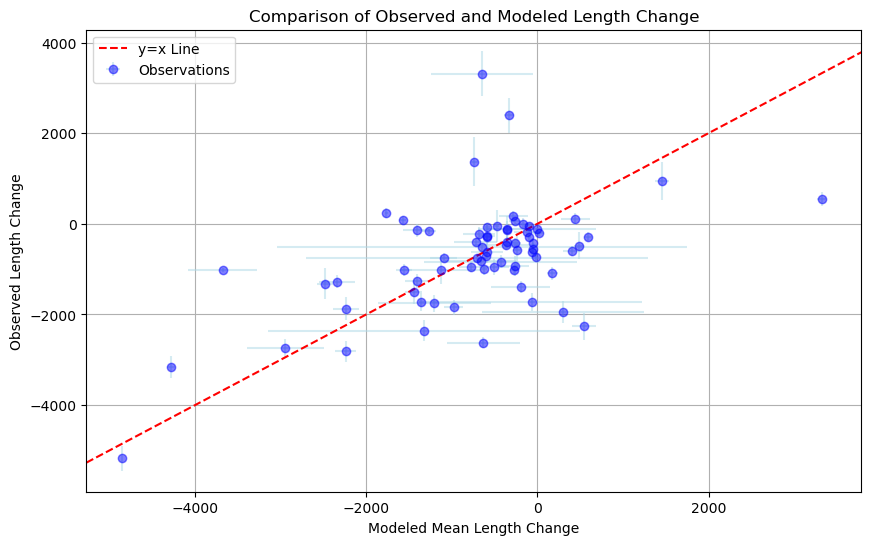

In [ ]:


# Convert length_change and length_change_unc to numeric
length_change_obs_20002020['length_change'] = pd.to_numeric(length_change_obs_20002020['length_change'], errors='coerce')
length_change_obs_20002020['length_change_unc'] = pd.to_numeric(length_change_obs_20002020['length_change_unc'], errors='coerce')

# Check if there are any NaN values
print(length_change_obs_20002020.isna().sum())

# Handle NaNs (Option 1: drop them)
length_change_obs_20002020 = length_change_obs_20002020.dropna(subset=['length_change', 'length_change_unc'])

# Alternatively, Option 2: fill NaNs with 0 or another appropriate value
# length_change_obs_20002020 = length_change_obs_20002020.fillna(0)

# Now you can proceed to merge and plot
merged_df = pd.merge(length_change_obs_20002020, sum_0020_dL_SQ_m, left_on='rgiid', right_on='rgiid')

# Check the converted DataFrame
print(merged_df[['rgiid', 'length_change', 'length_change_unc', 'mean', 'std']].head())

# Proceed with the plotting
plt.figure(figsize=(10, 6))
plt.errorbar(merged_df['mean'], merged_df['length_change'], 
             xerr=merged_df['std'], yerr=merged_df['length_change_unc'], 
             fmt='o', label='Observations', color='blue', ecolor='lightblue', alpha=0.5)

plt.title('Comparison of Observed and Modeled Length Change')
plt.xlabel('Modeled Mean Length Change')
plt.ylabel('Observed Length Change')
plt.axline((0, 0), slope=1, color='red', linestyle='--', label='y=x Line')
plt.legend()
plt.grid()
plt.show()


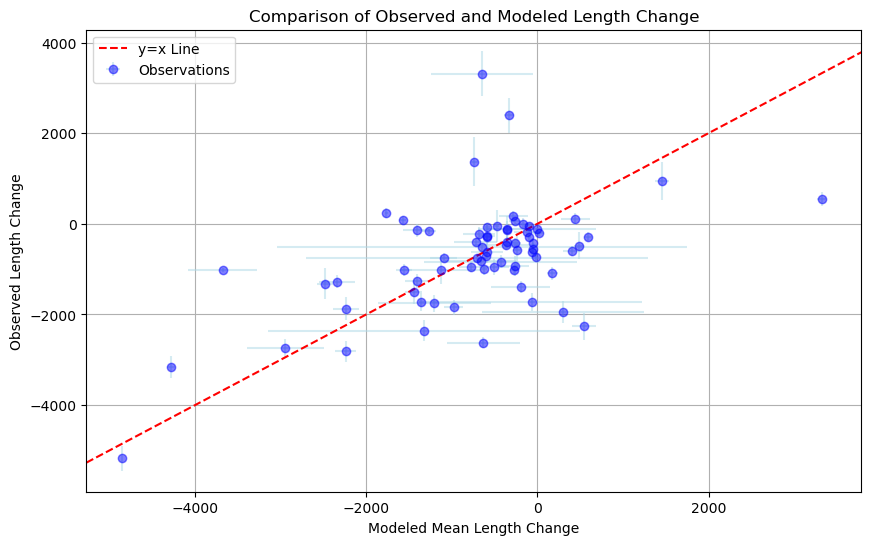

In [ ]:


# Assuming df_obs and df_model are your DataFrames
# Merge the observed and modeled results on RGIId
merged_df = pd.merge(length_change_obs_20002020, sum_0020_dL_SQ_m, left_on='rgiid', right_on='rgiid')

plt.figure(figsize=(10, 6))
plt.errorbar(merged_df['mean'], merged_df['length_change'], 
             xerr=merged_df['std'], yerr=merged_df['length_change_unc'], 
             fmt='o', label='Observations', color='blue', ecolor='lightblue', alpha=0.5)

plt.title('Comparison of Observed and Modeled Length Change')
plt.xlabel('Modeled Mean Length Change')
plt.ylabel('Observed Length Change')
plt.axline((0, 0), slope=1, color='red', linestyle='--', label='y=x Line')
plt.legend()
plt.grid()
plt.show()


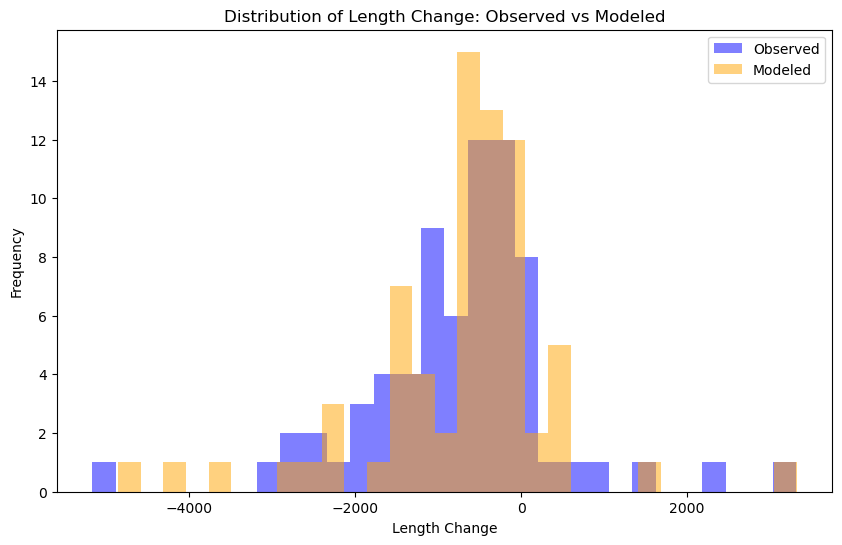

In [89]:
plt.figure(figsize=(10, 6))
plt.hist(length_change_obs_20002020['length_change'], bins=30, alpha=0.5, label='Observed', color='blue')
plt.hist(sum_0020_dL_SQ_m['mean'], bins=30, alpha=0.5, label='Modeled', color='orange')
plt.title('Distribution of Length Change: Observed vs Modeled')
plt.xlabel('Length Change')
plt.ylabel('Frequency')
plt.legend()
plt.show()


In [91]:
# Extracting lengths
observed_length_change = length_change_obs_20002020['length_change'].values
modeled_length_change = sum_0020_dL_SQ_m['mean'].values

# Print lengths for debugging
print("Length of observed data:", len(observed_length_change))
print("Length of modeled data:", len(modeled_length_change))


Length of observed data: 71
Length of modeled data: 71


In [92]:
# Display the RGIId values to identify potential missing ones
print("Observed RGIId values:", length_change_obs_20002020['rgiid'].unique())
print("Modeled RGIId values:", sum_0020_dL_SQ_m['rgiid'].unique())

# Finding RGIIds that are in observed but not in modeled
missing_in_modeled = set(length_change_obs_20002020['rgiid']) - set(sum_0020_dL_SQ_m['rgiid'])
print("RGIId values in observed but not in modeled:", missing_in_modeled)


Observed RGIId values: <ArrowStringArray>
['7.00025', '7.00026', '7.00027', '7.00029', '7.00031', '7.00036', '7.00042',
 '7.00060', '7.00061', '7.00064', '7.00224', '7.00250', '7.00251', '7.00276',
 '7.00277', '7.00301', '7.00315', '7.00425', '7.00448', '7.00463', '7.00464',
 '7.00465', '7.00468', '7.00470', '7.00471', '7.00474', '7.00502', '7.00551',
 '7.00552', '7.00558', '7.00645', '7.00659', '7.00681', '7.00682', '7.00714',
 '7.00715', '7.00724', '7.00727', '7.00733', '7.00789', '7.00790', '7.00791',
 '7.00794', '7.00832', '7.00854', '7.00859', '7.00874', '7.00883', '7.00892',
 '7.00896', '7.00903', '7.00910', '7.00945', '7.01328', '7.01353', '7.01449',
 '7.01458', '7.01464', '7.01487', '7.01488', '7.01492', '7.01493', '7.01494',
 '7.01499', '7.01500', '7.01503', '7.01506', '7.01507', '7.01559', '7.01560',
 '7.01561']
Length: 71, dtype: str
Modeled RGIId values: <ArrowStringArray>
['7.00025', '7.00026', '7.00027', '7.00029', '7.00031', '7.00036', '7.00042',
 '7.00060', '7.00061', '

In [93]:
# Merge the two DataFrames
merged_df = pd.merge(length_change_obs_20002020, sum_0020_dL_SQ_m, left_on='rgiid', right_on='rgiid', how='inner')

# Check the length of the merged DataFrame
print("Length of merged data:", len(merged_df))
print("Merged DataFrame head:")
print(merged_df.head())


Length of merged data: 71
Merged DataFrame head:
     rgiid  length_change  length_change_unc        mean      median  \
0  7.00025   -1847.202592         155.703562 -977.320963 -945.689620   
1  7.00026    1370.980536         545.419747 -735.913562 -737.534962   
2  7.00027    3315.900062         502.835242 -647.545754 -808.226718   
3  7.00029    -700.519754          82.051688 -595.239904 -594.185908   
4  7.00031    -278.901942         277.355644 -589.901812 -589.691134   

          std  percent_2.5  percent_25  percent_75  percent_97.5         mad  \
0  109.550492 -1198.149922 -997.047761 -945.689620   -806.472076   76.614166   
1   43.397608  -818.464080 -765.752371 -713.202365   -650.119320   31.217556   
2  591.103754 -1672.224197 -808.226718 -100.387035   -100.387035  505.674029   
3    8.387954  -608.094668 -601.020250 -589.563040   -575.232651    6.825217   
4   89.419880  -738.296748 -678.498312 -537.389724   -391.075993   69.466740   

    hdi_95_low  hdi_95_high  
0 -1198

# 4. Show the Good AMIS and Bad AMIS seperately

In [119]:
# read the AMIS INFO AND get the corresponding rgi info

In [ ]:
# regional postprocessing output path
AMIS_statis_fp_region = os.path.join(model_output_fp,'..','Statistics_model_run',reg_id)
print(AMIS_statis_fp_region)

In [121]:
rgiid_good = stats_t.extract_rgi_ids_robust(filepath=AMIS_statis_fp_region,filename='Good_AMIS.txt',max_iterations = 10)

In [122]:
# Sort by 'rgiid' in ascending order (default)
rgiid_good = rgiid_good.sort_values('rgiid')

In [124]:
rgiid_bad = stats_t.extract_rgi_ids(filepath=AMIS_statis_fp_region,filename='Bad_AMIS.txt')

In [126]:
merged_df = pd.merge(mb_obs_20102020_mwea, mean_1020_mb_clim_mwea, left_on='rgiid', right_on='rgiid', how='inner')


In [129]:
Good_AMIS = rgiid_good
Bad_AMIS = rgiid_bad



# Split the merged_df into two parts: one for good AMIS and one for bad AMIS
if Good_AMIS is not None:
    merged_df_good = merged_df[merged_df['rgiid'].isin(Good_AMIS['rgiid'])]
else:
    merged_df_good = merged_df
if Bad_AMIS is not None:
    merged_df_bad = merged_df[merged_df['rgiid'].isin(Bad_AMIS['rgiid'])]
else:
    merged_df_bad = pd.DataFrame()
# if just show the good
merged_df = merged_df_good

In [145]:
# Function to get the statistics information for the comparison of observed and modeled values
def get_statistics_compare(obs_change=None, obs_unc=None, hdi_high=None,hdi_low=None, model_mean=None,n_simulations=1000,
                           Loglevel = 'INFO',output_path = None,item_name = None,period = None,reg_id = None):
    """    Computes statistics for comparing observed and modeled values.
    Parameters:
    - obs_change (np.ndarray): Observed values.
    - obs_unc (np.ndarray): Uncertainty in observed values.
    - hdi_high (np.ndarray): High values of the highest density interval (HDI) for modeled values.
    - hdi_low (np.ndarray): Low values of the HDI for modeled values.
    - model_mean (np.ndarray): Mean of the modeled values.
    - n_simulations (int): Number of simulations for uncertainty adjustment. the default is 1000.
    - Loglevel (str): Logging level for output messages. Default is 'INFO'.
    - output_path (str): Path to save the output results. Default is None.
    - item_name (str): Name of the item being processed, used for logging. Default is None.
    - period (str): Time period for which the statistics are calculated, used for logging. Default is None.
    - reg_id (str): Region ID for which the statistics are calculated, used for logging. Default is None.
    Returns:
      dataframe with the following columns:

    - mean_d (float): Mean D statistic from K-S test.
    - mean_p (float): Mean p-value from K-S test.
    - nrmse (float): Normalized Root Mean Square Error.
    - coverage (float): Coverage of the HDI over the observed values.
    - overlap_hdi (float): Fraction of observations where the uncertainty range overlaps with the model
    - HDI_covs (np.ndarray): Boolean array indicating whether each observation is within the HDI.
    """
    # The output is a dataframe with the following columns:
    # mean_d, mean_p, nrmse, coverage, overlap_hdi, HDI_covs

    output_df = pd.DataFrame(columns=['mean_d', 'mean_p', 'nrmse', 'coverage', 'overlap_hdi', 'HDI_covs'])


    # Check if all inputs are provided
    if obs_change is None or obs_unc is None or hdi_high is None or hdi_low is None or model_mean is None:
        raise ValueError("All input arrays must be provided and not None.")
    # Check if all inputs are numpy arrays
    if not (isinstance(obs_change, np.ndarray) and isinstance(obs_unc, np.ndarray)
            and isinstance(hdi_high, np.ndarray) and isinstance(hdi_low, np.ndarray)
            and isinstance(model_mean, np.ndarray)):
        raise TypeError("All inputs must be numpy arrays.") 
    # Check if all input arrays have the same length
    if not (len(obs_change) == len(obs_unc) == len(hdi_high) == len(hdi_low) == len(model_mean)):
        raise ValueError("All input arrays must have the same length.") 
    # Ensure inputs are 1D arrays
    # --- (1) Compute K-S Test with Uncertainty ---
    d_values = []
    p_values = []
    
    for _ in range(n_simulations):
        # Perturb observations within uncertainty (Gaussian noise)
        perturbed_obs = obs_change + np.random.normal(0, obs_unc, size=len(obs_change))
        # Sample model predictions from HDI (uniform)
        perturbed_model = np.random.uniform(low=hdi_low, high=hdi_high, size=len(hdi_low))
        # K-S test
        d, p = ks_2samp(perturbed_obs, perturbed_model)
        d_values.append(d)
        p_values.append(p)
    
    mean_d = np.mean(d_values)
    mean_p = np.mean(p_values)
    
    # --- (2) Compute NRMSE ---
    nrmse = np.sqrt(np.mean((model_mean - obs_change)**2)) / np.mean(obs_unc)
    overlap_hdi = np.sum((obs_change - obs_unc <= hdi_high) & (obs_change + obs_unc >= hdi_low)) / len(obs_change)
    HDI_covs = (obs_change >= hdi_low) & (obs_change <= hdi_high)
    print("the HDI covers:",HDI_covs)
    coverage = np.mean(HDI_covs)

    # Print the results
    """
    if Loglevel in ['INFO', 'DEBUG']:
        with open(file_path_full, 'a') as f:
            f.write(f"============================================ {item_name} and {period}============================================ \n")
            f.write(f"Uncertainty-Adjusted K-S Test:\nD = {mean_d:.3f}, p = {mean_p:.3f}\nNRMSE = {nrmse:.3f}\n")
            f.write(f"Observed 10th percentile: {np.percentile(obs_change, 10)}\n")
            f.write(f"Model 10th percentile: {np.percentile(model_mean, 10)}\n")
            f.write(f"Observed 90th percentile: {np.percentile(obs_change, 90)}\n")
            f.write(f"Model 90th percentile: {np.percentile(model_mean, 90)}\n")
            f.write(f"HDI coverage: {coverage:.1%}\n")
            f.write(f"Uncertainty-overlap coverage: {overlap_hdi:.1%}\n")
    """

    # Store results in the output DataFrame
    output_df.loc[0] = [mean_d, mean_p, nrmse, coverage, overlap_hdi, HDI_covs]
    # Return the output DataFrame
    # Convert HDI coverage boolean array to a list for better readability
    HDI_covs = HDI_covs.tolist()
    output_df['HDI_covs'] = [HDI_covs]  # Store as a list in the DataFrame
    # Convert the output DataFrame to a tuple for return
    mean_d = output_df['mean_d'].values[0]
    mean_p = output_df['mean_p'].values[0]
    nrmse = output_df['nrmse'].values[0]
    coverage = output_df['coverage'].values[0]
    overlap_hdi = output_df['overlap_hdi'].values[0]
    HDI_covs = output_df['HDI_covs'].values[0]

    return output_df

In [146]:
# Function to clip lower errors to ensure values - err >= 0
def clip_errors( values=None,err=None,clip_lower= False):
    """Clip lower errors to ensure values - err >= 0.
    Parameters:
    - err (np.ndarray): Error values, can be symmetric or asymmetric.
    - values (np.ndarray): Corresponding values to which errors apply.
    - clip_lower (bool): If True, clip lower errors to ensure non-negativity.
    Returns:
    - np.ndarray: Clipped errors.
    """
    if err is None:
        return None
    err = np.asarray(err)
    if err.ndim == 2:  # Asymmetric errors [lower, upper]
        lower, upper = err
        lower_clipped = np.minimum(lower, values) if clip_lower else lower
        return [lower_clipped, upper]
    else:  # Symmetric errors
        return np.minimum(err, values) if clip_lower else err

In [217]:
# Function to compute CDF with observation uncertainty using Monte Carlo sampling
from turtle import pd


def cdf_with_obs_uncertainty_mc(values=None, uncertainties=None, n_mc=2000, x_grid=None):
    """
        Computes the CDF of observed values with uncertainties using Monte Carlo sampling.
        Parameters:
        - values (array-like): Array of observed values.
        - uncertainties (array-like): Array of uncertainties corresponding to the observed values.
        - n_mc (int): Number of Monte Carlo samples to generate for each observed value.
        - x_grid (array-like, optional): Grid of x values to evaluate the CDF. If None, it will be automatically generated based on the range of the samples.
        Returns:
        - x_grid (numpy array): Grid of x values where the CDF is evaluated.
        - cdf_med (numpy array): Median CDF values at each point in x_grid.
        - cdf_lo (numpy array): Lower bound of the 95% confidence interval for the CDF at each point in x_grid.
        - cdf_hi (numpy array): Upper bound of the 95% confidence interval for the CDF at each point in x_grid.
        This function generates Monte Carlo samples for each observed value based on its uncertainty, computes the empirical CDF for each set of samples, and then calculates the median and confidence intervals for the CDF across all Monte Carlo iterations.
    """
    values = np.asarray(values, float)
    uncertainties = np.asarray(uncertainties, float)

    mask = np.isfinite(values) & np.isfinite(uncertainties)
    values = values[mask]
    uncertainties = uncertainties[mask]

    n = len(values)

    samples = np.random.normal(
        loc=values[:, None],
        scale=uncertainties[:, None],
        size=(n, n_mc)
    )

    if x_grid is None:
        x_grid = np.linspace(
            np.nanmin(samples),
            np.nanmax(samples),
            600
        )

    ecdfs = np.zeros((n_mc, len(x_grid)))
    for k in range(n_mc):
        s = np.sort(samples[:, k])
        ecdfs[k] = np.searchsorted(s, x_grid, side="right") / n

    cdf_med, cdf_lo, cdf_hi = np.percentile(ecdfs, [50, 2.5, 97.5], axis=0)
    return x_grid, cdf_med, cdf_lo, cdf_hi


# Function to compute CDF from model ensemble and calculate median and confidence intervals
def cdf_from_model_ensemble(model_ensemble =None, x_grid=None):
    """
    Docstring for cdf_from_model_ensemble
    
    :param model_ensemble: model ensemble array of shape (n_glaciers, n_ens)
    :param x_grid: x grid to evaluate the CDF
    :return: median CDF, 2.5th percentile CDF, 97.5th percentile CDF
    """ 
    n_glaciers, n_ens = model_ensemble.shape
    ecdfs = np.zeros((n_ens, len(x_grid)))

    for j in range(n_ens):
        s = np.sort(model_ensemble[:, j])
        ecdfs[j] = np.searchsorted(s, x_grid, side='right') / n_glaciers

    return np.percentile(ecdfs, [50, 2.5, 97.5], axis=0)



# Function to compute K-S statistic with observation uncertainty using Monte Carlo sampling
def ks_with_uncertainty_mc(
    obs=None, obs_unc=None, model_ensemble=None,
    n_mc=2000):
    """
    Computes the K-S statistic between observed values with uncertainties and a model ensemble using Monte Carlo sampling.
    Parameters:
    - obs (array-like): Array of observed values.
    - obs_unc (array-like): Array of uncertainties corresponding to the observed values.
    - model_ensemble (2D array-like): 2D array where each row corresponds to a glacier and each column to an ensemble member.
    - n_mc (int): Number of Monte Carlo samples to generate.
    Returns:
    - dict: Dictionary containing the median, 2.5th percentile, and 97.5th percentile of the K-S statistics.
    """
    obs = np.asarray(obs, float)
    obs_unc = np.asarray(obs_unc, float)

    mask = np.isfinite(obs) & np.isfinite(obs_unc)
    obs = obs[mask]
    obs_unc = obs_unc[mask]
    model_ensemble = model_ensemble[mask, :]

    n_glaciers, n_ens = model_ensemble.shape
    ks_stats = np.zeros(n_mc)

    for k in range(n_mc):
        obs_sample = np.random.normal(obs, obs_unc)
        ens_idx = np.random.randint(0, n_ens)
        model_sample = model_ensemble[:, ens_idx]

        ks_stats[k] = ks_2samp(obs_sample, model_sample).statistic

    return {
        "KS_median": np.median(ks_stats),
        "KS_2p5": np.percentile(ks_stats, 2.5),
        "KS_97p5": np.percentile(ks_stats, 97.5)
    }



# Function to compute per-glacier model performance metrics using MC sampling, with glacier ID
import numpy as np
import pandas as pd
from scipy.stats import ks_2samp
import os

def per_glacier_model_eval(
    obs = None,
    obs_unc = None,
    model_ensemble = None,
    rgiid = None,
    n_mc=2000,
    save_path=None,
    save_name="per_glacier_model_eval.csv",
    AMIS_type=None,
    period=None,
    item_name=None,
    random_state=None
):
    """
    Glacier-wise model evaluation consistent with:
    - Ensemble boxplots vs observational error bars
    - Population-level CDF / KS diagnostics (external)

    Each glacier is evaluated independently.

    Parameters:
    - obs: array-like, observed values for each glacier
    - obs_unc: array-like, uncertainties of the observed values
    - model_ensemble: 2D array-like, shape (n_glaciers, n_ensemble_members), model predictions for each glacier
    - rgiid: array-like, glacier IDs corresponding to the observations
    - n_mc: int, number of Monte Carlo samples for uncertainty propagation
    - save_path: str, directory to save the results CSV
    - save_name: str, name of the results CSV file
    - AMIS_type: str, type of AMIS data
    - period: str, time period of the data
    - item_name: str, name of the item being evaluated (e.g., "Length Change")
    - random_state: int or None, random seed for reproducibility, here we use it to ensure the same Monte Carlo samples are generated for consistent results across runs, e.g. 42

    Per-glacier metrics:
    - CRPS
    - Normalized CRPS (CRPS / obs σ)
    - Obs inside ensemble IQR (25–75%)
    - Obs inside ensemble 5–95% interval
    - Overlap fraction: obs ±1σ vs ensemble min–max
    - MC probability obs lies inside ensemble min–max

    Summary statistics represent FRACTIONS OF GLACIERS,
    not ensemble probabilities.
    """
    rng = np.random.default_rng(random_state)

    obs = np.asarray(obs, float)
    obs_unc = np.asarray(obs_unc, float)
    model_ensemble = np.asarray(model_ensemble, float)
    rgiid = np.asarray(rgiid)

    # -------------------------------------------------
    # Valid glaciers
    # -------------------------------------------------
    mask = (
        np.isfinite(obs) &
        np.isfinite(obs_unc) &
        (obs_unc >= 0) &
        np.any(np.isfinite(model_ensemble), axis=1)
    )

    obs = obs[mask]
    obs_unc = obs_unc[mask]
    model_ensemble = model_ensemble[mask]
    rgiid = rgiid[mask]

    results = []

    # -------------------------------------------------
    # Loop over glaciers
    # -------------------------------------------------
    for i in range(len(obs)):
        obs_val = obs[i]
        obs_sigma = obs_unc[i]

        ensemble = model_ensemble[i]
        ensemble = ensemble[np.isfinite(ensemble)]

        # ---- Monte Carlo obs samples
        obs_samples = rng.normal(obs_val, obs_sigma, n_mc)

        # ---- CRPS
        term1 = np.mean(np.abs(ensemble[:, None] - obs_samples[None, :]))
        term2 = 0.5 * np.mean(
            np.abs(ensemble[:, None] - ensemble[None, :])
        )
        crps = term1 - term2
        ncrps = crps / obs_sigma if obs_sigma > 0 else np.nan

        # ---- Ensemble quantiles
        q25, q75 = np.percentile(ensemble, [25, 75])
        q025, q975 = np.percentile(ensemble, [2.5, 97.5])

        obs_in_IQR = (q25 <= obs_val <= q75)
        obs_in_2p5_97p5 = (q025 <= obs_val <= q975)

        # ---- MC probability obs in ensemble min–max
        ens_min, ens_max = ensemble.min(), ensemble.max()
        p_inside = np.mean(
            (obs_samples >= ens_min) & (obs_samples <= ens_max)
        )

        # ---- Overlap: obs ±1σ vs ensemble range
        lower_obs = obs_val - obs_sigma
        upper_obs = obs_val + obs_sigma
        obs_range = upper_obs - lower_obs

        if obs_range == 0:
            overlap = float(ens_min <= obs_val <= ens_max)
        else:
            overlap = max(
                0.0,
                min(upper_obs, ens_max) - max(lower_obs, ens_min)
            ) / obs_range

        results.append({
            "rgiid": rgiid[i],
            "CRPS": crps,
            "nCRPS": ncrps,
            "obs_in_IQR": obs_in_IQR,
            "obs_in_2p5_97p5": obs_in_2p5_97p5,
            "overlap_fraction": overlap,
            "p_inside_ensemble": p_inside
        })

    df = pd.DataFrame(results)

    # -------------------------------------------------
    # Glacier-wise summary (fractions of glaciers)
    # -------------------------------------------------
    print(f"====== Per-Glacier Model Evaluation Summary ({AMIS_type}) ======")
    print(f"Number of glaciers evaluated: {len(df)}")
    print("")
    print(f"Median CRPS: {df['CRPS'].median():.3f}")
    print(f"Median normalized CRPS (CRPS / σ_obs): {df['nCRPS'].median():.3f}")
    print("")
    print(
        "Fraction of glaciers with obs inside ensemble IQR (25–75%): "
        f"{df['obs_in_IQR'].mean() * 100:.1f}%"
    )
    print(
        "Fraction of glaciers with obs inside ensemble 2.5–97.5% interval: "
        f"{df['obs_in_2p5_97p5'].mean() * 100:.1f}%"
    )
    print(
        f"Mean overlap fraction (obs ±1σ vs ensemble range): "
        f"{df['overlap_fraction'].mean():.3f}"
    )
    print("=================================================")

    # -------------------------------------------------
    # Save results
    # -------------------------------------------------
    if save_path is None:
        save_path = os.getcwd()
    os.makedirs(save_path, exist_ok=True)

    if AMIS_type is not None:
        save_name = (
            f"{item_name.replace(' ', '_')}_"
            f"{period.replace('-', '_')}_"
            f"{AMIS_type}_"
            f"{save_name}"
        )

    save_file = os.path.join(save_path, save_name)
    df.to_csv(save_file, index=False)
    print(f"Saved per-glacier metrics to: {save_file}")

    return df






# Function to compute CDF overlap percentage between observed and modeled CDFs 
def cdf_overlap_percent(
    x = None,
    cdf_obs_med = None,
    cdf_model_med = None):
    """
    Docstring for cdf_overlap_percent
    
    :param x: Observation grid
    :param cdf_obs_med: CDF of observed median
    :param cdf_model_med: CDF of modeled median
    """ 
    dx = np.diff(x)
    diff = np.abs(cdf_obs_med[:-1] - cdf_model_med[:-1])
    overlap = 1.0 - np.sum(diff * dx) / (x[-1] - x[0])
    return 100 * overlap


# Function to plot CDF and one-to-one comparison with box plots and error bars, with options for good/bad AMIS, log scales, and inset zoom
def plot_cdf_and_one_to_one_Good_Bad_All_Inset (observed_df = None, modeled_df = None, modeled_df_raw= None,
                            obs_name = None, obs_unc_name = None, modeled_key = None, item_name = None,
                            period = None, reg_id = None,Xlabel = None, Ylabel = None,Xlim = None, Ylim = None,
                            subplot_label_L = 'a', subplot_label_R = 'b',title= None, save_path=None, save_name=None,
                            legend_index = True,Good_AMIS = None,Bad_AMIS = None,logx = False,logy= False,inset_zoom = False,Good_bad = True,
                            zoom_xlim = None, zoom_ylim = None,zoom_position = None,zoom_ticklabels = None):
    """
    Plots the CDF for observed and modeled values,
    and a one-to-one comparison with box plots for modeled results and error bars for observations.
    Parameters:
    - observed_df (pd.DataFrame): DataFrame containing observed values with columns e.g. 'rgiid', 'length_change', 'length_change_unc'.
    - modeled_df (pd.DataFrame): DataFrame containing modeled values with columns 'rgiid', 'mean', 'hdi_95_low', 'hdi_95_high'.
    - modeled_df_raw (pd.DataFrame): DataFrame containing raw modeled values for box plots, with 'rgiid' and 'lengthchange_dLdt_model_array_annual_myr' columns.
    - obs_name (str): Name of the observed length change column in observed_df, e.g. 'length_change'.
    - obs_unc_name (str): Name of the observed length change uncertainty column in observed_df, e.g. 'length_change_unc'.
    - modeled_key (str): Key for the modeled values in modeled_df, e.g. 'lengthchange_dLdt_model_array_annual_myr'.
    - item_name (str): Name of the item to be compare, e.g. 'Length Change'.
    - period (str): Period for the data, e.g. '2000-2010'.
    - reg_id (str): Region ID for the data, e.g. '07'.
    - Xlabel (str): Label for the x-axis. e.g. 'Length Change (m, observed)', 'Climatic Mass Balance (m w.e. a$^{-1}$, observed)'.
    - Ylabel (str): Label for the y-axis. e.g. 'Length Change (m, modeled)', 'Climatic Mass Balance (m w.e. a$^{-1}$, modeled)''.
    - Xlim (tuple): Limits for the x-axis, e.g. (0, 1000).
    - Ylim (tuple): Limits for the y-axis, e.g. (0, 1000).
    - subplot_label_L (str): Label for the left subplot, e.g. 'a)'.
    - subplot_label_R (str): Label for the right subplot, e.g. 'b)'.
    - title (str): Title for the plot.
    - save_path (str): Path to save the plot.
    - save_name (str): Name to save the plot file.
    - Good_AMIS (df): List of good AMIS rgiid to highlight in the plot.
    - Bad_AMIS (df): List of bad AMIS rgiid to highlight in the plot.
    - logx (bool): If True, apply logarithmic scale to x-axis.
    - logy (bool): If True, apply logarithmic scale to y-axis.
    - inset_zoom (bool): If True, add an inset zoom to the plot.
    - Good_bad (bool): If True, plot good and bad AMIS separately, otherwise plot all together.
    - zoom_xlim (tuple): Limits for the x-axis of the inset zoom, e.g. (0, 100).
    - zoom_ylim (tuple): Limits for the y-axis of the inset zoom, e.g. (0, 100).
    - zoom_position (array): Specifies the position and size of the inset zoom in the plot, given as [x, y, width, height], where [0.6, 0.6, 0.25, 0.25] means that the inset zoom is located at (0.6, 0.6) in the coordinate system, with a width and height of 0.25.
    - zoom_ticklabels (bool): If True, show tick labels in the inset zoom, otherwise hide them, and  show the connection lines between the inset zoom and the main plot.
    Returns:
    - None: Displays the plot and saves it to the specified path.
    - The function also computes K-S statistics comparing observed and modeled data for good and bad AMIS.
    - The function also handles the case where the modeled_key column is not present in the raw DataFrame.
    - The function also handles the case where the observed_df and modeled_df do not have the same 'rgiid' values.
    - The function also handles the case where the observed_df and modeled_df have different lengths, ensuring that the merge operation does not fail.
    - The function also handles the case where the observed_df and modeled_df have different columns, ensuring that the specified obs_name and obs_unc_name are present in the observed_df.
    - The function also handles the case where the modeled_df does not have the 'mean', 'hdi_95_low', and 'hdi_95_high' columns, ensuring that the merge operation does not fail.
    - The function also handles the case where the modeled_df_raw does not have the modeled_key column, ensuring that the box plots are created correctly.
    """
    # Merge DataFrames
    merged_df = pd.merge(observed_df, modeled_df, left_on='rgiid', right_on='rgiid', how='inner')
    rgiid = merged_df['rgiid'].values
    #=============================================
    # Split the merged_df into two parts: one for good AMIS and one for bad AMIS
    if Good_AMIS is not None:
        merged_df_good = merged_df[merged_df['rgiid'].isin(Good_AMIS['rgiid'])]
        merged_df_raw_good = modeled_df_raw[modeled_df_raw['rgiid'].isin(Good_AMIS['rgiid'])]
        rgiids_good = merged_df_good['rgiid'].values
        # Ensure the modeled_key column exists in the raw DataFrame
    else:
        merged_df_good = pd.DataFrame()
        merged_df_raw_good = pd.DataFrame()
        rgiids_good = []
    if Bad_AMIS is not None:
        merged_df_bad = merged_df[merged_df['rgiid'].isin(Bad_AMIS['rgiid'])]
        merged_df_raw_bad = modeled_df_raw[modeled_df_raw['rgiid'].isin(Bad_AMIS['rgiid'])]
        rgiids_bad = merged_df_bad['rgiid'].values
    else:
        merged_df_bad = pd.DataFrame()
        merged_df_raw_bad = pd.DataFrame()
        rgiids_bad = []


    #=============================================
    # setting the saving path
    if save_path is None:
        save_path = os.path.join(pygem_prms.output_filepath,'Calibration','Postprocessing',reg_id,'Regional_analysis/figures/')
    else:
        save_path = os.path.join(save_path, 'Regional_analysis', 'figures')
        os.makedirs(save_path, exist_ok=True)
    # if just show the good
    #merged_df = merged_df_good
    #modeled_df_raw = modeled_df_raw[modeled_df_raw['rgiid'].isin(Good_AMIS['rgiid'])]

    #print('good_AMIS:',merged_df_good)
    #print('merged_df_raw_good:', merged_df_raw_good.shape)
    #print('merged_df_raw_bad:', merged_df_raw_bad.shape)
    #=============================================
    


    # Extract data
    # scale the length change from m to km
    # clip, to make sure the value of varibles are non-negative
    if obs_name == 'length_change':
        scale_v = 0.001  # Changed from 0.0001 to properly convert m to km
        clip_lower = False
    elif obs_name in ['fa_gta_obs', 'fa_mwea_obs']:
        scale_v =1
        clip_lower = True
    else:
        scale_v = 1
        clip_lower = False
    #  obs and obs_unc for good and bad AMIS
    obs_change_good = merged_df_good[obs_name].values * scale_v
    obs_unc_good = merged_df_good[obs_unc_name].values * scale_v
    obs_change_bad = merged_df_bad[obs_name].values * scale_v
    obs_unc_bad = merged_df_bad[obs_unc_name].values * scale_v
    #  modeled values for good and bad AMIS
    model_mean_good = merged_df_good['mean'].values * scale_v
    hdi_low_good, hdi_high_good = merged_df_good['hdi_95_low'].values * scale_v, merged_df_good['hdi_95_high'].values * scale_v
    model_mean_bad = merged_df_bad['mean'].values * scale_v
    hdi_low_bad, hdi_high_bad = merged_df_bad['hdi_95_low'].values * scale_v, merged_df_bad['hdi_95_high'].values * scale_v

    #  modeled values for raw data
    obs_change = merged_df[obs_name].values * scale_v
    obs_unc = merged_df[obs_unc_name].values * scale_v
    model_mean = merged_df['mean'].values * scale_v
    hdi_low, hdi_high = merged_df['hdi_95_low'].values * scale_v, merged_df['hdi_95_high'].values * scale_v

    # model ensemble from raw data for good and bad AMIS

    model_ensemble_good = np.vstack([np.asarray(row[modeled_key], float) * scale_v for _, row in merged_df_raw_good.iterrows()])
    model_ensemble_bad = np.vstack([np.asarray(row[modeled_key], float) * scale_v for _, row in merged_df_raw_bad.iterrows()])
    model_ensemble = np.vstack([np.asarray(row[modeled_key], float) * scale_v for _, row in modeled_df_raw.iterrows()])

    #===================================================
    # track metrics for each glaciers
    per_glacier_metrics_good = per_glacier_model_eval(obs=obs_change_good, obs_unc=obs_unc_good, model_ensemble=model_ensemble_good,
                                                      rgiid=rgiids_good, n_mc=2000, save_path=save_path, AMIS_type='good', period=period, item_name=item_name, random_state=42)
    per_glacier_metrics_bad = per_glacier_model_eval(obs=obs_change_bad, obs_unc=obs_unc_bad, model_ensemble=model_ensemble_bad,
                                                     rgiid=rgiids_bad, n_mc=2000, save_path=save_path, AMIS_type='bad', period=period, item_name=item_name, random_state=42)
    per_glacier_metrics_all = per_glacier_model_eval(obs=obs_change, obs_unc=obs_unc, model_ensemble=model_ensemble,
                                                     rgiid= rgiid, n_mc=2000, save_path=save_path, AMIS_type='all', period=period, item_name=item_name, random_state=42)

    
    #===================================================
    # --- (1) Compute K-S Test with Uncertainty ---
    # statis_compare_good =get_statistics_compare(obs_change=obs_change_good, obs_unc=obs_unc_good, hdi_high=hdi_high_good,
    #                        hdi_low=hdi_low_good, model_mean=model_mean_good,n_simulations=1000,item_name = item_name,period = period,reg_id =reg_id)
    # statis_compare_bad =get_statistics_compare(obs_change=obs_change_bad, obs_unc=obs_unc_bad, hdi_high=hdi_high_bad,
    #                        hdi_low=hdi_low_bad, model_mean=model_mean_bad,n_simulations=1000,item_name = item_name,period = period,reg_id =reg_id)
    # statis_compare_all =get_statistics_compare(obs_change=obs_change, obs_unc=obs_unc, hdi_high=hdi_high,
    #                     hdi_low=hdi_low, model_mean=model_mean,n_simulations=1000,item_name = item_name,period = period,reg_id =reg_id)
    KS_statistics = ks_with_uncertainty_mc(obs=obs_change, obs_unc=obs_unc, model_ensemble=model_ensemble, n_mc=2000)
    KS_statistics_good = ks_with_uncertainty_mc(obs=obs_change_good, obs_unc=obs_unc_good, model_ensemble=model_ensemble_good, n_mc=2000)
    KS_statistics_bad = ks_with_uncertainty_mc(obs=obs_change_bad, obs_unc=obs_unc_bad, model_ensemble=model_ensemble_bad, n_mc=2000)   
    print("K-S Statistics (All AMIS):", KS_statistics)
    print("K-S Statistics (Good AMIS):", KS_statistics_good)
    print("K-S Statistics (Bad AMIS):", KS_statistics_bad)
    #===================================================
    # Create figure with proper layout management
    fig = plt.figure(figsize=(10, 5), constrained_layout=True)
    #fig.suptitle(title, fontsize=18, y=1.02)

    # Create gridspec with adjusted margins
    gs = GridSpec(1, 2, figure=fig, width_ratios=[1, 1], height_ratios=[1], wspace=0.17, 
                  left=0.04, right=0.86, bottom=0.15, top=0.9)
    

    ###### ============================================ subplot 1  ============================================
    # --- One-to-One Plot with Boxplots (left subplot) ---
    ax1 = fig.add_subplot(gs[0])

    # Create boxplot data for each RGI ID using ensemble results, for good and bad AMIS
    box_data = []
    box_data_bad = []
    box_data_good = []
    for _, row in modeled_df_raw.iterrows():
        # Convert string representation to numpy array if needed
        if isinstance(row[modeled_key], str):
            # More robust string to array conversion
            ensemble_members = np.array([float(x) for x in row[modeled_key].strip('[]').split()]) * scale_v
        else:
            ensemble_members = np.array(row[modeled_key]) * scale_v
        box_data.append(ensemble_members)  # THIS WAS MISSING IN ORIGINAL CODE
    for _, row in merged_df_raw_good.iterrows():
        # Convert string representation to numpy array if needed
        if isinstance(row[modeled_key], str):
            # More robust string to array conversion
            ensemble_members = np.array([float(x) for x in row[modeled_key].strip('[]').split()]) * scale_v
        else:
            ensemble_members = np.array(row[modeled_key]) * scale_v
        box_data_good.append(ensemble_members)
    for _, row in merged_df_raw_bad.iterrows():
        # Convert string representation to numpy array if needed
        if isinstance(row[modeled_key], str):
            # More robust string to array conversion
            ensemble_members = np.array([float(x) for x in row[modeled_key].strip('[]').split()]) * scale_v
        else:
            ensemble_members = np.array(row[modeled_key]) * scale_v
        box_data_bad.append(ensemble_members)
    

    # Calculate default limits if not provided
    if Xlim is None:
        all_box_values = np.concatenate(box_data)
        Xlim = (min(obs_change.min(), all_box_values.min()), 
                max(obs_change.max(), all_box_values.max()))
    if Ylim is None:
        Ylim = Xlim  # Use same limits for y-axis

    # Position boxes at observed value positions
    box_positions = obs_change
    box_widths = 0.05 * (Xlim[1] - Xlim[0])  # 5% of total x-range

    boxprops = dict(facecolor='orange', alpha=0.3, edgecolor='orange', linewidth=1.5)
    whiskerprops = dict(color='orange', alpha=0.8)
    medianprops = dict(color='orange', linewidth=1.5)
    capprops = dict(color='orange', linewidth=1.5)

    # Position boxes for good and bad AMIS
    box_colors_good = "#FA7507"
    box_colors_bad = "#F8C0D7F8" 

    box_positions_good = obs_change_good
    box_positions_bad = obs_change_bad
    box_widths_good = 0.05 * (Xlim[1] - Xlim[0])  # 5% of total x-range
    box_widths_bad = 0.05 * (Xlim[1] - Xlim[0])  # 5% of total x-range

    # Styling properties for good boxes
    boxprops_good = dict(facecolor=box_colors_good, alpha=0.5, edgecolor=box_colors_good, linewidth=1.5)
    whiskerprops_good = dict(color=box_colors_good, alpha=0.5)
    medianprops_good = dict(color=box_colors_good, alpha=0.5, linewidth=1.5)
    capprops_good = dict(color=box_colors_good,  alpha=0.5,linewidth=1.5)

    # Styling properties for bad boxes
    boxprops_bad = dict(facecolor= box_colors_bad, edgecolor=box_colors_bad,alpha=0.5, linewidth=1.5)
    whiskerprops_bad = dict(color=box_colors_bad, alpha=0.5)
    medianprops_bad = dict(color=box_colors_bad, alpha=0.5,linewidth=1.5)
    capprops_bad = dict(color=box_colors_bad, alpha=0.5, linewidth=1.5)


    # ============================================ plot the boxplots and error bars
    # Check the lengths of box_data and box_positions
    if len(box_data) != len(box_positions):
        raise ValueError(f"Length mismatch for all boxes: box_data ({len(box_data)}) != box_positions ({len(box_positions)})")
    if len(box_data_good) != len(box_positions_good):
        raise ValueError(f"Length mismatch for good boxes: box_data_good ({len(box_data_good)}) != box_positions_good ({len(box_positions_good)})")
    if len(box_data_bad) != len(box_positions_bad):
        raise ValueError(f"Length mismatch for bad boxes: box_data_bad ({len(box_data_bad)}) != box_positions_bad ({len(box_positions_bad)})")
    
    if Good_bad:
        # plot good 
        ax1.boxplot(box_data_good,
                positions=box_positions_good,
                widths=box_widths_good,
                patch_artist=True,
                boxprops=boxprops_good,
                whiskerprops=whiskerprops_good,
                medianprops=medianprops_good,
                capprops=capprops_good,
                showfliers=False,
                manage_ticks=False)

        # Plot bad boxes
        ax1.boxplot(box_data_bad,
                positions=box_positions_bad,
                widths=box_widths_bad,
                patch_artist=True,
                boxprops=boxprops_bad,
                whiskerprops=whiskerprops_bad,
                medianprops=medianprops_bad,
                capprops=capprops_bad,
                showfliers=False,
                manage_ticks=False)

        # Create proxy artists for the legend
        good_box_legend = plt.Line2D([0], [0], color=box_colors_good, alpha=0.5, lw=5, label=' Modeled (converged)')
        bad_box_legend = plt.Line2D([0], [0], color=box_colors_bad, alpha=0.5, lw=5, label='Modeled (unconverged)')

        # plot error bars for good AMIS
        errorbar_color_good =  "#031CF8"  # Color for error bars for good AMIS
        errorbar_color_bad = "#5A91F8"  # Color for error bars for bad AMIS
        # Plot good AMIS points with circle markers
        # Clip the errors to ensure non-negativity
        if not merged_df_good.empty:
            good_obs_change = merged_df_good[obs_name].values * scale_v
            good_obs_unc = merged_df_good[obs_unc_name].values * scale_v
            good_model_mean = merged_df_good['mean'].values * scale_v
            xerr_good_clipped = clip_errors(good_obs_change,good_obs_unc,clip_lower)
            # print('good_obs_change is :',good_obs_change)
            # print('xerr (origianl unc) is:',good_obs_unc)
            # print("==========================")
            # print('xerr_clipped is:',xerr_good_clipped)
                
            ax1.errorbar(good_obs_change, good_model_mean,
                    xerr=xerr_good_clipped, markersize=3,
                    fmt='o', color=errorbar_color_good, alpha=0.7,
                    label='Observed (converged)',mfc=errorbar_color_good, capsize=3)
        # Plot bad AMIS points with square markers
        if not merged_df_bad.empty:
            bad_obs_change = merged_df_bad[obs_name].values * scale_v
            bad_obs_unc = merged_df_bad[obs_unc_name].values * scale_v
            bad_model_mean = merged_df_bad['mean'].values * scale_v
            xerr_bad_clipped = clip_errors(bad_obs_change,bad_obs_unc,clip_lower)
            # print('bad_obs_change is :',bad_obs_change)
            # print('xerr (origianl unc) is:',bad_obs_unc)
            # print("==========================")
            # print('xerr_clipped is:',xerr_bad_clipped)
            ax1.errorbar(bad_obs_change, bad_model_mean,
                    xerr=xerr_bad_clipped, markersize=3,
                    fmt='o', color=errorbar_color_bad, alpha=0.7,
                    label='Observed (unconverged)',mfc= 'none',  capsize=3)
    else:
        # Plot all boxes together
        ax1.boxplot(box_data,
                positions=box_positions,
                widths=box_widths,
                patch_artist=True,
                boxprops=boxprops,
                whiskerprops=whiskerprops,
                medianprops=medianprops,
                capprops=capprops,
                showfliers=False,
                manage_ticks=False)
        # Create a proxy artist for the legend
        box_legend = plt.Line2D([0], [0], color='orange', alpha=0.5, lw=5, label='Modeled')

        # plot the error bars for all AMIS
        # Clip the errors to ensure non-negativity
        xerr_clipped = clip_errors(obs_change, obs_unc, clip_lower)
            # Plot values with error bars
        ax1.errorbar(obs_change, model_mean,
                  xerr=xerr_clipped, markersize=4,
                 fmt='o', color='blue', alpha=0.7,
                 label='Observed', capsize=3)


    # =========================================plot the one-to-one line
    ax1.plot(Xlim, Xlim, 'k--', label='')

    # Configure plot
    # Update labels based on log flags
    xlabel = f"log₁₀({Xlabel})" if logx else Xlabel
    ylabel = f"log₁₀({Ylabel})" if logy else Ylabel
    ax1.set(xlabel=xlabel,ylabel=ylabel,aspect='equal')

    # ============================================scale the xaxis,yaxis
    # Set log scales if needed
    if logx: 
        ax1.set_xscale('log')
    if logy:
        ax1.set_yscale('log')
    
    # Get min/max values (handling log scales)
    x_valid = obs_change[obs_change > 0] if logx else obs_change
    y_valid = np.concatenate([x for x in box_data if x is not None])
    if logy: 
        y_valid = y_valid[y_valid > 0]

    if logx and logy:
        # Set equal limits with 10% padding
        lim_min = min(np.min(x_valid), np.min(y_valid)) * (0.9 if logx or logy else 1)
        lim_max = max(np.max(x_valid), np.max(y_valid)) * (1.1 if logx or logy else 1)
        ax1.set_xlim(lim_min, lim_max)
        ax1.set_ylim(lim_min, lim_max) 
        # Force square plot
        ax1.set_aspect('equal', adjustable='box')
    else:
        # Set limits based on provided Xlim and Ylim
        ax1.set_xlim(Xlim)
        ax1.set_ylim(Ylim)
    
    #ax1.legend(handles=ax1.get_legend_handles_labels()[0] + [box_legend])
    # ============================================ set the grid
    #ax1.grid(linestyle='--')
    ax1.grid(False)
    # ============================================ set legend
    if legend_index:
        # Get existing handles and labels
        handles, labels = ax1.get_legend_handles_labels()
        if Good_bad:
            # Create proxy artists for both boxplot types
            good_box_legend = plt.Line2D([0], [0], color=box_colors_good, alpha=0.5, lw=5, label='Modeled (converged)')
            bad_box_legend = plt.Line2D([0], [0], color=box_colors_bad, alpha=0.5, lw=5, label='Modeled (unconverged)')
            
            # Add the boxplot legends to existing handles/labels
            handles.extend([good_box_legend, bad_box_legend])
            labels.extend(['Modeled (converged)', 'Modeled (unconverged)'])
        else:
            # Create a proxy artist for the boxplot
            box_legend = plt.Line2D([0], [0], color='orange', alpha=0.5, lw=5, label='Modeled')
            
            # Add the boxplot legend to existing handles/labels
            handles.append(box_legend)
            labels.append('Modeled')
        
        # Update the legend with all handles and labels
        # Set legend with shorter lines and tighter spacing
        ax1.legend(handles=handles, labels=labels, 
                handlelength=1,   # shorter line length
                handletextpad=0.8, # less space between line and text
                frameon=False,
                loc='lower right',
                bbox_to_anchor=(1.02, -0.02))

    else:
        # If legend_index is False, hide the legend completely
        ax1.legend().set_visible(False)

    # ============================================ add the title and labels
    if title is not None:
        ax1.set_title(title, fontsize=16, pad=10)
    # Add 'a)' label outside top-left
    ax1.annotate(subplot_label_L, xy=(-0.13, 0.96), xycoords='axes fraction',
                fontsize=18, weight='normal', ha='left', va='bottom',
                bbox=dict(facecolor='white', edgecolor='none', pad=0))
    
    # ============================================ add zoom in inset
    if inset_zoom:
        # Ensure zoom_xlim and zoom_ylim are provided or set defaults
        if zoom_xlim is None:
            zoom_xlim = (0, 1)
        if zoom_ylim is None:
            zoom_ylim = (0, 1)
        # Ensure the zoom limits are within the main plot limits
        zoom_xlim = (max(zoom_xlim[0], Xlim[0]), min(zoom_xlim[1], Xlim[1]))
        zoom_ylim = (max(zoom_ylim[0], Ylim[0]), min(zoom_ylim[1], Ylim[1]))
    
        # Create inset axes in the lower left corner
        axins = ax1.inset_axes(zoom_position)  # [x, y, width, height] in axes coordinates[0.7, 0.7, 0.28, 0.28]
        
        # Replot the main content in the inset
        if Good_bad:
            # Plot good and bad seperately   
            if not merged_df_good.empty:
                axins.errorbar(good_obs_change, good_model_mean,
                            xerr=xerr_good_clipped, markersize=2,
                            fmt='o', color=errorbar_color_good, alpha=0.7,
                            mfc=errorbar_color_good, capsize=2)
                
            if not merged_df_bad.empty:
                axins.errorbar(bad_obs_change, bad_model_mean,
                            xerr=xerr_bad_clipped, markersize=2,
                            fmt='o', color=errorbar_color_bad, alpha=0.7,
                            mfc='none', capsize=2)
            
            # Plot boxes in inset (with smaller widths)
            box_widths_zoom = 0.03 * (zoom_xlim[1] - zoom_xlim[0])
            
            if len(box_data_good) > 0:
                axins.boxplot(box_data_good,
                            positions=box_positions_good,
                            widths=box_widths_zoom,
                            patch_artist=True,
                            boxprops=boxprops_good,
                            whiskerprops=whiskerprops_good,
                            medianprops=medianprops_good,
                            capprops=capprops_good,
                            showfliers=False,
                            manage_ticks=False)
            
            if len(box_data_bad) > 0:
                axins.boxplot(box_data_bad,
                            positions=box_positions_bad,
                            widths=box_widths_zoom,
                            patch_artist=True,
                            boxprops=boxprops_bad,
                            whiskerprops=whiskerprops_bad,
                            medianprops=medianprops_bad,
                            capprops=capprops_bad,
                            showfliers=False,
                            manage_ticks=False)
        else:
            # Plot all together
            axins.errorbar(obs_change, model_mean,
                        xerr=xerr_clipped, markersize=2,
                        fmt='o', color='blue', alpha=0.7,
                        label='Observed', capsize=2)
            # Plot boxes in inset (with smaller widths)
            box_widths_zoom = 0.03 * (zoom_xlim[1] - zoom_xlim[0])
            axins.boxplot(box_data,
                        positions=box_positions,
                        widths=box_widths_zoom,
                        patch_artist=True,
                        boxprops=boxprops,
                        whiskerprops=whiskerprops,
                        medianprops=medianprops,
                        capprops=capprops,
                        showfliers=False,
                        manage_ticks=False)
        # Configure the inset
        axins.plot(zoom_xlim, zoom_xlim, 'k--', linewidth=0.5)
        axins.set_xlim(zoom_xlim)
        axins.set_ylim(zoom_ylim)

        # set the tick labels
        if zoom_ticklabels:
            # Customize tick labels - smaller font size, fewer ticks
            axins.set_xticks(np.linspace(zoom_xlim[0], zoom_xlim[1], 3))  # 3 ticks for x-axis
            axins.set_yticks(np.linspace(zoom_ylim[0], zoom_ylim[1], 3))  # 3 ticks for y-axis
            # Format tick labels - adjust fontsize as needed
            axins.tick_params(axis='both', which='major', labelsize=6)  # Smaller font for inset
        else:
            axins.set_xticklabels([])
            axins.set_yticklabels([])
            # Connect the inset to the main plot
            axins.indicate_inset_zoom(ax1, edgecolor='black', alpha=0.3)
            # Add connection lines
        # add the grid for axins
        #axins.grid(True, linestyle=':', alpha=0.3)
        axins.grid(False)

    ###### =========================================== subplot 2 =================================
    # --- CDF Plot (right subplot) ---
    ax2 = fig.add_subplot(gs[1])
    
    if Good_bad:
        # In the CDF plot section:
        if not merged_df_bad.empty:
            # Plot CDF for bad AMIS observed values

            x_obs_bad, cdf_med_bad, cdf_lo_bad, cdf_hi_bad = (
                cdf_with_obs_uncertainty_mc(
                    bad_obs_change,
                    bad_obs_unc,
                    n_mc=2000
                )
            )

            ax2.plot(
                x_obs_bad,
                cdf_med_bad,
                color=errorbar_color_bad,
                linestyle='--',
                label='Observed (unconverged)'
            )

            ax2.fill_between(
                x_obs_bad,
                cdf_lo_bad,
                cdf_hi_bad,
                color=errorbar_color_bad,
                alpha=0.3
            ) 
            # Plot CDF for bad AMIS modeled values
            #sns.ecdfplot(model_mean_bad, ax=ax2, label='Modeled (unconverged)', color=box_colors_bad, linestyle='--')
            cdf_med_m_bad, cdf_lo_m_bad, cdf_hi_m_bad = cdf_from_model_ensemble(
                model_ensemble=model_ensemble_bad,  # shape (n_glaciers, 200)
                x_grid=x_obs_bad
            )

            ax2.plot(
                x_obs_bad,
                cdf_med_m_bad,
                color=box_colors_bad,
                linestyle='--',
                label='Modeled (unconverged)'
            )

            ax2.fill_between(
                x_obs_bad,
                cdf_lo_m_bad,
                cdf_hi_m_bad,
                color=box_colors_bad,
                alpha=0.3
            )

            # Calculate CDF overlap percentage for bad AMIS
            overlap_pct_bad= cdf_overlap_percent(x = x_obs_bad, cdf_obs_med = cdf_med_bad, cdf_model_med = cdf_med_m_bad)

            print(f"CDF overlap for bad AMIS (Observed vs Modeled): {overlap_pct_bad:.1f}%")
        if not merged_df_good.empty:
            # Plot CDF for good AMIS observed values
            #sns.ecdfplot(good_obs_change, ax=ax2, label='Observed (converged)', color= errorbar_color_good,linestyle='-')
            x_obs_good, cdf_med_good, cdf_lo_good, cdf_hi_good = (
                cdf_with_obs_uncertainty_mc(
                    good_obs_change,
                    good_obs_unc,
                    n_mc=2000
                )
            )

            ax2.plot(
                x_obs_good,
                cdf_med_good,
                color=errorbar_color_good,
                linestyle='-',
                label='Observed (converged)'
            )

            ax2.fill_between(
                x_obs_good,
                cdf_lo_good,
                cdf_hi_good,
                color=errorbar_color_good,
                alpha=0.3
            )
            # Plot CDF for good AMIS modeled values
            #sns.ecdfplot(model_mean_good, ax=ax2, label='Modeled (converged)', color=box_colors_good, linestyle='-')

            cdf_med_m_good, cdf_lo_m_good, cdf_hi_m_good = cdf_from_model_ensemble(
                model_ensemble=model_ensemble_good,  # shape (n_glaciers, 200)
                x_grid=x_obs_good
            )

            ax2.plot(
                x_obs_good,
                cdf_med_m_good,
                color=box_colors_good,
                linestyle='-',
                label='Modeled (converged)'
            )

            ax2.fill_between(
                x_obs_good,
                cdf_lo_m_good,
                cdf_hi_m_good,
                color=box_colors_good,
                alpha=0.3
            )
            # Calculate CDF overlap percentage for good AMIS
            overlap_pct_good= cdf_overlap_percent(x = x_obs_good, cdf_obs_med = cdf_med_good, cdf_model_med = cdf_med_m_good)

            print(f"CDF overlap for good AMIS (Observed vs Modeled): {overlap_pct_good:.1f}%")
    else:
        # Plot observed CDF and uncertainty for all AMIS together
        # Calculate and plot observed uncertainty band
        x_obs, cdf_med, cdf_lo, cdf_hi = (
            cdf_with_obs_uncertainty_mc(
                obs_change,
                obs_unc,
                n_mc=2000
            )
        )

        ax2.plot(
            x_obs,
            cdf_med,
            color='blue',
            linestyle='-',
            label='Observed'
        )

        ax2.fill_between(
            x_obs,
            cdf_lo,
            cdf_hi,
            color='blue',
            alpha=0.3
        )

        # Plot modeled CDF and HDI
        #sns.ecdfplot(model_mean, ax=ax2, label='Modeled', color='orange')
        cdf_med_m, cdf_lo_m, cdf_hi_m = cdf_from_model_ensemble(
            model_ensemble=model_ensemble,  # shape (n_glaciers, 200)
            x_grid=x_obs
        )
        ax2.plot(
            x_obs,
            cdf_med_m,
            color='orange',
            linestyle='-',
            label='Modeled'
        )
        ax2.fill_between(
            x_obs,
            cdf_lo_m,
            cdf_hi_m,
            color='orange',
            alpha=0.3,
            label='Modeled Uncertainty'
        )
    
        overlap_pct = cdf_overlap_percent(x = x_obs, cdf_obs_med = cdf_med, cdf_model_med = cdf_med_m)

        print(f"CDF overlap (Observed vs Modeled): {overlap_pct:.1f}%")
    # Set x-label and y-label
    if logx:
        xlabel = f"log₁₀({item_name})"
    else:
        xlabel = item_name
    ax2.set_xlabel(xlabel)
    ax2.set_ylabel('Cumulative Probability')

    # Set x-axis scaling and limits based on conditions
    if logx:
        ax2.set_xscale('log')
        valid_vals = obs_change[obs_change > 0]
        if len(valid_vals) > 0:
            min_value = valid_vals.min() * 0.5
            ax2.set_xlim(left=min(min_value, lim_min), right=lim_max)
        else:
            ax2.set_xlim(left=lim_min, right=lim_max)
    elif clip_lower:
        ax2.set_xlim(left=0, right=Xlim[1])
    else:
        ax2.set_xlim(Xlim)


    # ============================================= set grid and legend
    # set the grid
    #ax2.grid(linestyle='--')
    ax2.grid(False)
    #set the legend
    if legend_index:
        # If legend_index is True, show the legend including existing handles
        handles = ax2.get_legend_handles_labels()[0]
        ax2.legend(handles=handles, frameon=False)
    else:
        # If legend_index is False, do not show the legend at all
        ax2.legend().set_visible(False)

    # ============================================= add the annotation and title
    # Add 'b)' label outside top-left
    ax2.annotate(subplot_label_R, xy=(-0.14, 0.96), xycoords='axes fraction',
                fontsize=18, weight='normal', ha='left', va='bottom',
                bbox=dict(facecolor='white', edgecolor='none', pad=0))

    ###### ============================================ adjust the layout and save the figure
    # Adjust layout and save
    plt.tight_layout()
    # Save the figure

    if save_name is None:
        if Good_bad and inset_zoom:
            save_name = f'{item_name.replace(" ", "_")}_{period.replace("-", "_")}_cdf_comparison_GOOD_BAD_inset_zoom'
        elif Good_bad:
            save_name = f'{item_name.replace(" ", "_")}_{period.replace("-", "_")}_cdf_comparison_GOOD_BAD'
        elif inset_zoom:
            save_name = f'{item_name.replace(" ", "_")}_{period.replace("-", "_")}_cdf_comparison_inset_zoom'
        else:
            save_name = f'{item_name.replace(" ", "_")}_{period.replace("-", "_")}_cdf_comparison'

        # add the logx and logy to the save name
        if logx:
            save_name += '_log'

    save_file = os.path.join(save_path, f"{save_name}_Updated.png")
    plt.savefig(save_file, bbox_inches='tight', dpi=300)
    #plt.show()
    
    

====== Per-Glacier Model Evaluation Summary (good) ======
Number of glaciers evaluated: 62

Median CRPS: 0.023
Median normalized CRPS (CRPS / σ_obs): 4.427

Fraction of glaciers with obs inside ensemble IQR (25–75%): 8.1%
Fraction of glaciers with obs inside ensemble 2.5–97.5% interval: 21.0%
Mean overlap fraction (obs ±1σ vs ensemble range): 0.235
Saved per-glacier metrics to: /home/ruitang/Astra_UIO_Ruitang/SermeQ_PyGEM_OGGM/Output/Calibration/modeloutput/../Postprocessing/07/Regional_analysis/figures/Frontal_ablation_(Gt_a$^{-1}$)_2010_2020_good_per_glacier_model_eval.csv
====== Per-Glacier Model Evaluation Summary (bad) ======
Number of glaciers evaluated: 9

Median CRPS: 0.057
Median normalized CRPS (CRPS / σ_obs): 3.623

Fraction of glaciers with obs inside ensemble IQR (25–75%): 11.1%
Fraction of glaciers with obs inside ensemble 2.5–97.5% interval: 11.1%
Mean overlap fraction (obs ±1σ vs ensemble range): 0.087
Saved per-glacier metrics to: /home/ruitang/Astra_UIO_Ruitang/SermeQ

/tmp/ipykernel_1250493/422390528.py:1023: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_1250493/422390528.py:1023: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


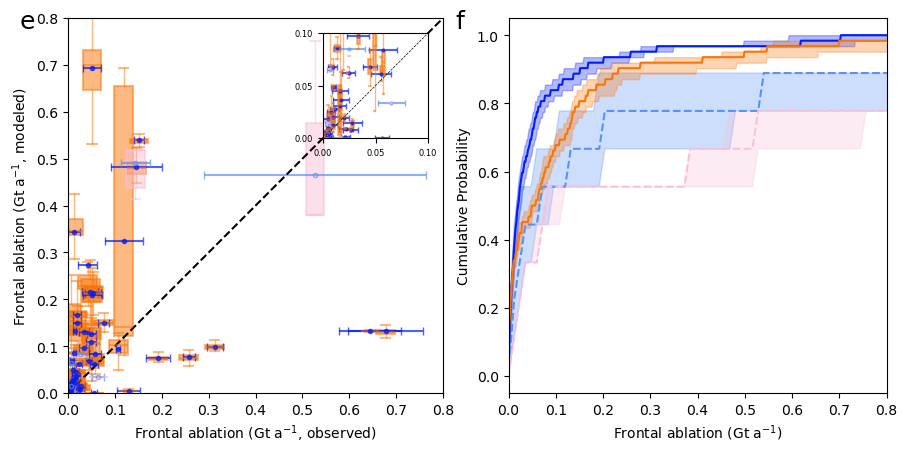

In [219]:
plot_cdf_and_one_to_one_Good_Bad_All_Inset(observed_df = fa_obs_20102020_gta, modeled_df = mean_1020_FA_Gta, modeled_df_raw= mean_1020_FA_raw_Gta,
                            obs_name = 'fa_gta_obs' , obs_unc_name = 'fa_gta_obs_unc', modeled_key = 'calving_flux_Gta_TMS_model_array_annual', item_name = 'Frontal ablation (Gt a$^{-1}$)',
                            period = '2010-2020',reg_id = reg_id,Xlabel = 'Frontal ablation (Gt a$^{-1}$, observed)',Ylabel = 'Frontal ablation (Gt a$^{-1}$, modeled)', 
                        Xlim = (0,0.8), Ylim = (0,0.8),subplot_label_L ='e', subplot_label_R = 'f',title= None, save_path = postpro_output_fp_region, save_name=None,Good_AMIS = rgiid_good,Bad_AMIS = rgiid_bad,
                                 legend_index = False,logx=False,logy=False,inset_zoom = True,Good_bad = True,
                            zoom_xlim = (0,0.1), zoom_ylim = (0,0.1),zoom_position = [0.68, 0.68, 0.28, 0.28],zoom_ticklabels = True)

====== Per-Glacier Model Evaluation Summary (good) ======
Number of glaciers evaluated: 62

Median CRPS: 0.292
Median normalized CRPS (CRPS / σ_obs): 3.223

Fraction of glaciers with obs inside ensemble IQR (25–75%): 17.7%
Fraction of glaciers with obs inside ensemble 2.5–97.5% interval: 33.9%
Mean overlap fraction (obs ±1σ vs ensemble range): 0.404
Saved per-glacier metrics to: /home/ruitang/Astra_UIO_Ruitang/SermeQ_PyGEM_OGGM/Output/Calibration/modeloutput/../Postprocessing/07/Regional_analysis/figures/Length_change_(km)_2010_2020_good_per_glacier_model_eval.csv
====== Per-Glacier Model Evaluation Summary (bad) ======
Number of glaciers evaluated: 9

Median CRPS: 0.838
Median normalized CRPS (CRPS / σ_obs): 5.254

Fraction of glaciers with obs inside ensemble IQR (25–75%): 11.1%
Fraction of glaciers with obs inside ensemble 2.5–97.5% interval: 11.1%
Mean overlap fraction (obs ±1σ vs ensemble range): 0.111
Saved per-glacier metrics to: /home/ruitang/Astra_UIO_Ruitang/SermeQ_PyGEM_OGGM

/tmp/ipykernel_1250493/422390528.py:1023: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_1250493/422390528.py:1023: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


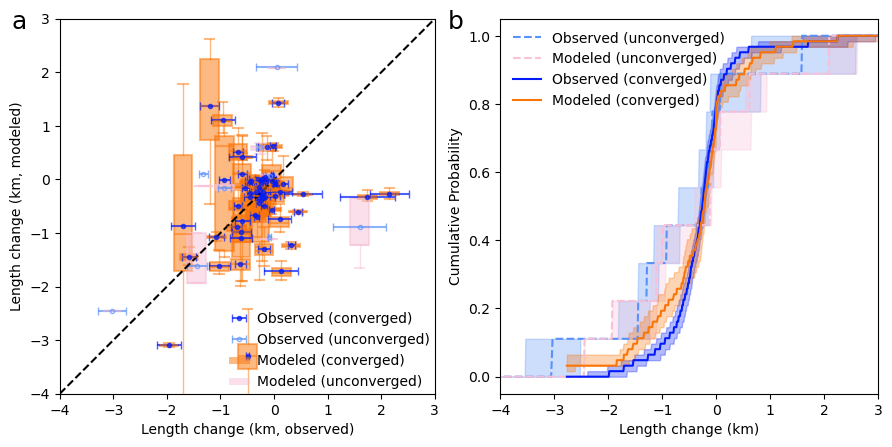

In [242]:
plot_cdf_and_one_to_one_Good_Bad_All_Inset(observed_df = length_change_obs_20102020, modeled_df = sum_1020_dL_SQ_m, modeled_df_raw= sum_dL_SQ_1020_raw_m,
                            obs_name = 'length_change' , obs_unc_name = 'length_change_unc', modeled_key = 'lengthchange_dLdt_model_array_annual_myr', item_name = 'Length change (km)',
                            period = '2010-2020',reg_id = reg_id,Xlabel = 'Length change (km, observed)',Ylabel = 'Length change (km, modeled)', 
                        Xlim = (-4,3), Ylim = (-4,3),subplot_label_L ='a', subplot_label_R = 'b',title= None, save_path = postpro_output_fp_region, save_name=None,Good_AMIS = rgiid_good,Bad_AMIS = rgiid_bad,
                                 legend_index = True,logx=False,logy=False,inset_zoom = False,Good_bad = True,
                            zoom_xlim = (0,0.1), zoom_ylim = (0,0.1),zoom_position = [0.68, 0.68, 0.28, 0.28],zoom_ticklabels = True)

====== Per-Glacier Model Evaluation Summary (good) ======
Number of glaciers evaluated: 62

Median CRPS: 0.393
Median normalized CRPS (CRPS / σ_obs): 1.895

Fraction of glaciers with obs inside ensemble IQR (25–75%): 11.3%
Fraction of glaciers with obs inside ensemble 2.5–97.5% interval: 27.4%
Mean overlap fraction (obs ±1σ vs ensemble range): 0.392
Saved per-glacier metrics to: /home/ruitang/Astra_UIO_Ruitang/SermeQ_PyGEM_OGGM/Output/Calibration/modeloutput/../Postprocessing/07/Regional_analysis/figures/Climatic_mass_balance_(m_w.e._a$^{-1}$)_2010_2020_good_per_glacier_model_eval.csv
====== Per-Glacier Model Evaluation Summary (bad) ======
Number of glaciers evaluated: 9

Median CRPS: 0.779
Median normalized CRPS (CRPS / σ_obs): 3.747

Fraction of glaciers with obs inside ensemble IQR (25–75%): 0.0%
Fraction of glaciers with obs inside ensemble 2.5–97.5% interval: 0.0%
Mean overlap fraction (obs ±1σ vs ensemble range): 0.000
Saved per-glacier metrics to: /home/ruitang/Astra_UIO_Ruitan

/tmp/ipykernel_1250493/422390528.py:1023: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_1250493/422390528.py:1023: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


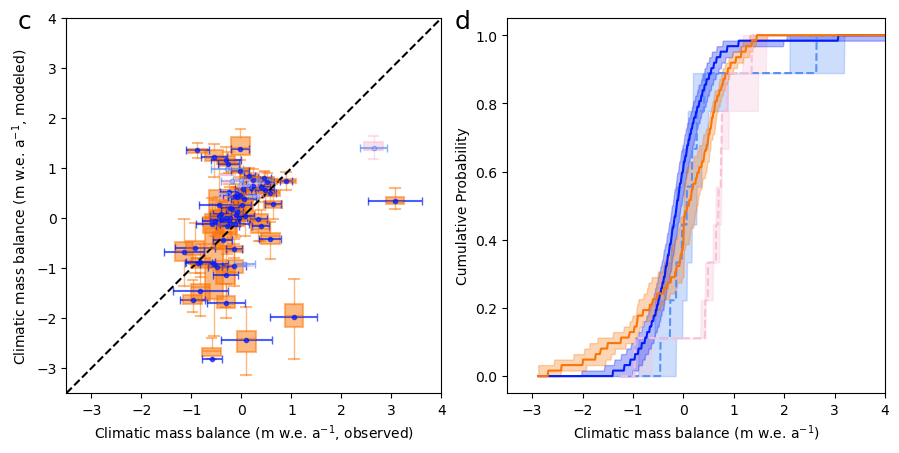

In [222]:
plot_cdf_and_one_to_one_Good_Bad_All_Inset(observed_df = mb_obs_20102020_mwea, modeled_df = mean_1020_mb_clim_mwea, modeled_df_raw= mean_MB_clim_1020_raw_mwe,
                            obs_name = 'mb_clim_mwea' , obs_unc_name = 'mb_clim_mwea_err', modeled_key = 'massbalclim_TMS_model_array_annual_mwea', item_name = 'Climatic mass balance (m w.e. a$^{-1}$)',
                            period = '2010-2020',reg_id = reg_id,Xlabel = 'Climatic mass balance (m w.e. a$^{-1}$, observed)',Ylabel = 'Climatic mass balance (m w.e. a$^{-1}$, modeled)', Xlim = (-3.5,4), Ylim = (-3.5,4),
                            subplot_label_L ='c', subplot_label_R = 'd',title= None, save_path = postpro_output_fp_region, save_name=None,Good_AMIS = rgiid_good,Bad_AMIS = rgiid_bad,
                                 legend_index = False,logx=False,logy=False,inset_zoom = False,Good_bad = True,
                            zoom_xlim = (0,0.1), zoom_ylim = (0,0.1),zoom_position = [0.68, 0.68, 0.28, 0.28],zoom_ticklabels = True)

====== Per-Glacier Model Evaluation Summary (good) ======
Number of glaciers evaluated: 62

Median CRPS: 0.454
Median normalized CRPS (CRPS / σ_obs): 1.604

Fraction of glaciers with obs inside ensemble IQR (25–75%): 8.1%
Fraction of glaciers with obs inside ensemble 2.5–97.5% interval: 25.8%
Mean overlap fraction (obs ±1σ vs ensemble range): 0.336
Saved per-glacier metrics to: /home/ruitang/Astra_UIO_Ruitang/SermeQ_PyGEM_OGGM/Output/Calibration/modeloutput/../Postprocessing/07/Regional_analysis/figures/Climatic_mass_balance_(m_w.e._a$^{-1}$)_2000_2010_good_per_glacier_model_eval.csv
====== Per-Glacier Model Evaluation Summary (bad) ======
Number of glaciers evaluated: 9

Median CRPS: 0.759
Median normalized CRPS (CRPS / σ_obs): 3.181

Fraction of glaciers with obs inside ensemble IQR (25–75%): 0.0%
Fraction of glaciers with obs inside ensemble 2.5–97.5% interval: 0.0%
Mean overlap fraction (obs ±1σ vs ensemble range): 0.097
Saved per-glacier metrics to: /home/ruitang/Astra_UIO_Ruitang

/tmp/ipykernel_1250493/422390528.py:1023: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_1250493/422390528.py:1023: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


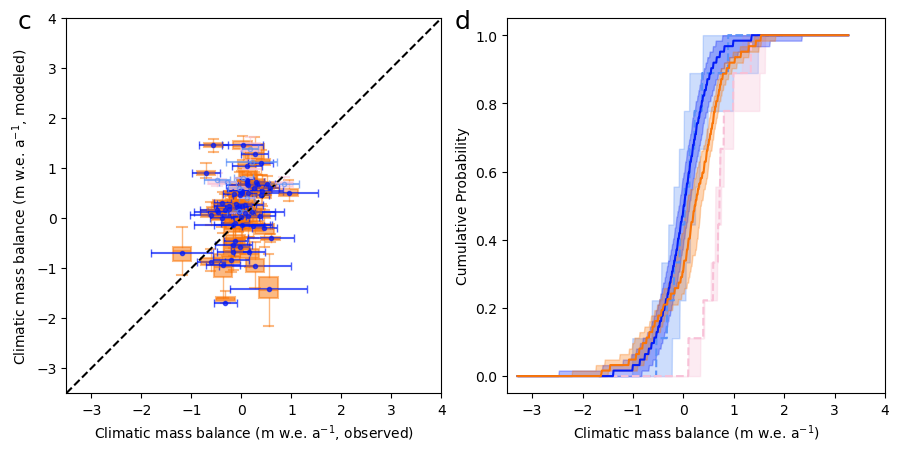

In [223]:
plot_cdf_and_one_to_one_Good_Bad_All_Inset(observed_df = mb_obs_20002010_mwea, modeled_df = mean_0010_mb_clim_mwea, modeled_df_raw= mean_MB_clim_0010_raw_mwe,
                            obs_name = 'mb_clim_mwea' , obs_unc_name = 'mb_clim_mwea_err', modeled_key = 'massbalclim_TMS_model_array_annual_mwea', item_name = 'Climatic mass balance (m w.e. a$^{-1}$)',
                            period = '2000-2010',reg_id = reg_id,Xlabel = 'Climatic mass balance (m w.e. a$^{-1}$, observed)',Ylabel = 'Climatic mass balance (m w.e. a$^{-1}$, modeled)', Xlim = (-3.5,4), Ylim = (-3.5,4),
                            subplot_label_L ='c', subplot_label_R = 'd',title= None, save_path = postpro_output_fp_region, save_name=None,Good_AMIS = rgiid_good,Bad_AMIS = rgiid_bad,
                                 legend_index = False,logx=False,logy=False,inset_zoom = False,Good_bad = True,
                            zoom_xlim = (0,0.1), zoom_ylim = (0,0.1),zoom_position = [0.68, 0.68, 0.28, 0.28],zoom_ticklabels = True)

====== Per-Glacier Model Evaluation Summary (good) ======
Number of glaciers evaluated: 62

Median CRPS: 0.017
Median normalized CRPS (CRPS / σ_obs): 1.124

Fraction of glaciers with obs inside ensemble IQR (25–75%): 9.7%
Fraction of glaciers with obs inside ensemble 2.5–97.5% interval: 29.0%
Mean overlap fraction (obs ±1σ vs ensemble range): 0.305
Saved per-glacier metrics to: /home/ruitang/Astra_UIO_Ruitang/SermeQ_PyGEM_OGGM/Output/Calibration/modeloutput/../Postprocessing/07/Regional_analysis/figures/Frontal_ablation_(Gt_a$^{-1}$)_2000_2010_good_per_glacier_model_eval.csv
====== Per-Glacier Model Evaluation Summary (bad) ======
Number of glaciers evaluated: 9

Median CRPS: 0.532
Median normalized CRPS (CRPS / σ_obs): 11.079

Fraction of glaciers with obs inside ensemble IQR (25–75%): 0.0%
Fraction of glaciers with obs inside ensemble 2.5–97.5% interval: 0.0%
Mean overlap fraction (obs ±1σ vs ensemble range): 0.001
Saved per-glacier metrics to: /home/ruitang/Astra_UIO_Ruitang/SermeQ_

/tmp/ipykernel_1250493/422390528.py:1023: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_1250493/422390528.py:1023: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


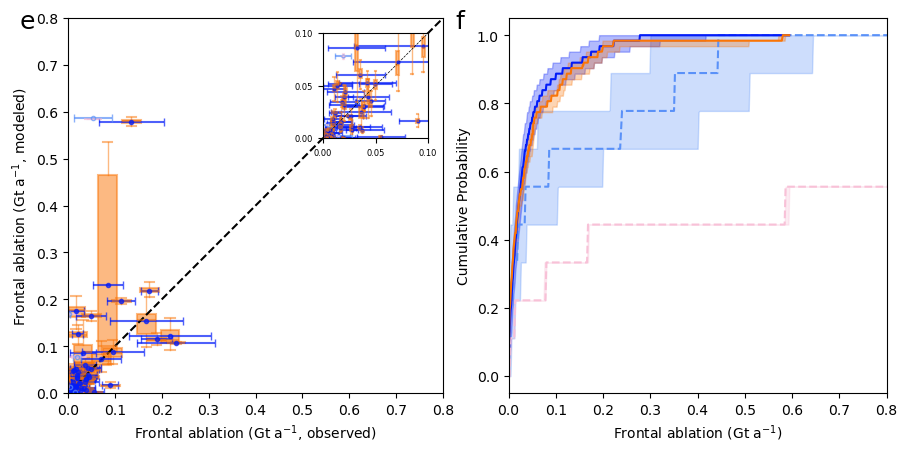

In [224]:
plot_cdf_and_one_to_one_Good_Bad_All_Inset(observed_df = fa_obs_20002010_gta, modeled_df = mean_0010_FA_Gta, modeled_df_raw= mean_0010_FA_raw_Gta,
                            obs_name = 'fa_gta_obs' , obs_unc_name = 'fa_gta_obs_unc', modeled_key = 'calving_flux_Gta_TMS_model_array_annual', item_name = 'Frontal ablation (Gt a$^{-1}$)',
                            period = '2000-2010',reg_id = reg_id,Xlabel = 'Frontal ablation (Gt a$^{-1}$, observed)',Ylabel = 'Frontal ablation (Gt a$^{-1}$, modeled)', 
                        Xlim = (0,0.8), Ylim = (0,0.8),subplot_label_L ='e', subplot_label_R = 'f',title= None, save_path = postpro_output_fp_region, save_name=None,Good_AMIS = rgiid_good,Bad_AMIS = rgiid_bad,
                                 legend_index = False,logx=False,logy=False,inset_zoom = True,Good_bad = True,
                            zoom_xlim = (0,0.1), zoom_ylim = (0,0.1),zoom_position = [0.68, 0.68, 0.28, 0.28],zoom_ticklabels = True)

====== Per-Glacier Model Evaluation Summary (good) ======
Number of glaciers evaluated: 62

Median CRPS: 0.182
Median normalized CRPS (CRPS / σ_obs): 1.503

Fraction of glaciers with obs inside ensemble IQR (25–75%): 16.1%
Fraction of glaciers with obs inside ensemble 2.5–97.5% interval: 30.6%
Mean overlap fraction (obs ±1σ vs ensemble range): 0.385
Saved per-glacier metrics to: /home/ruitang/Astra_UIO_Ruitang/SermeQ_PyGEM_OGGM/Output/Calibration/modeloutput/../Postprocessing/07/Regional_analysis/figures/Length_change_(km)_2000_2010_good_per_glacier_model_eval.csv
====== Per-Glacier Model Evaluation Summary (bad) ======
Number of glaciers evaluated: 9

Median CRPS: 0.113
Median normalized CRPS (CRPS / σ_obs): 2.381

Fraction of glaciers with obs inside ensemble IQR (25–75%): 0.0%
Fraction of glaciers with obs inside ensemble 2.5–97.5% interval: 11.1%
Mean overlap fraction (obs ±1σ vs ensemble range): 0.177
Saved per-glacier metrics to: /home/ruitang/Astra_UIO_Ruitang/SermeQ_PyGEM_OGGM/

/tmp/ipykernel_1250493/422390528.py:1023: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_1250493/422390528.py:1023: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


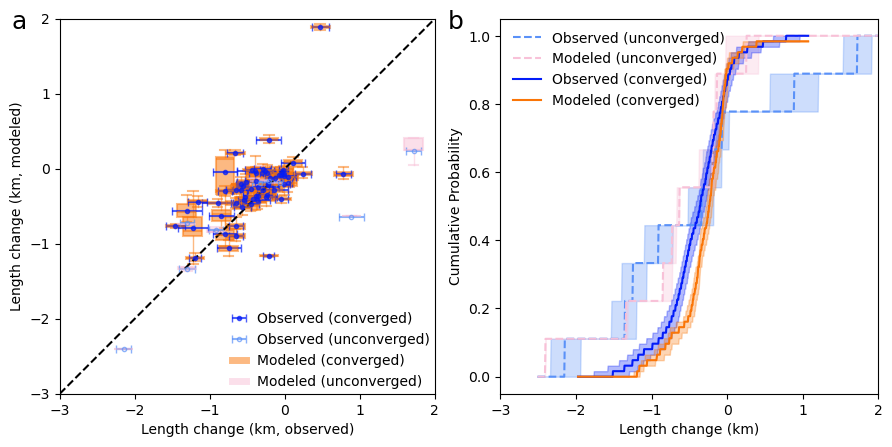

In [241]:
plot_cdf_and_one_to_one_Good_Bad_All_Inset(observed_df = length_change_obs_20002010, modeled_df = sum_0010_dL_SQ_m, modeled_df_raw= sum_dL_SQ_0010_raw_m,
                            obs_name = 'length_change' , obs_unc_name = 'length_change_unc', modeled_key = 'lengthchange_dLdt_model_array_annual_myr', item_name = 'Length change (km)',
                            period = '2000-2010',reg_id = reg_id,Xlabel = 'Length change (km, observed)',Ylabel = 'Length change (km, modeled)', 
                        Xlim = (-3,2), Ylim = (-3,2),subplot_label_L ='a', subplot_label_R = 'b',title= None, save_path = postpro_output_fp_region, save_name=None,Good_AMIS = rgiid_good,Bad_AMIS = rgiid_bad,
                                 legend_index = True,logx=False,logy=False,inset_zoom = False,Good_bad = True,
                            zoom_xlim = (0,0.1), zoom_ylim = (0,0.1),zoom_position = [0.68, 0.68, 0.28, 0.28],zoom_ticklabels = True)